In [161]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, entropy
from sdv.single_table import GaussianCopulaSynthesizer
from sdv.metadata import SingleTableMetadata

# DIRECT MATCHING

The direct matching dataset contains the best 10 candidates for each job position. In this case we are only looking at job offers

In [162]:
#path to be changed with correct one for your device
dm_df_ita = pd.read_csv(r'C:\Users\annad\Desktop\AI_in_industry\Adecco_Dataset\direct_matching_20240213.csv', encoding='Windows-1252', sep = ';')

In [163]:
dm_df_eng = pd.read_csv(r'C:\Users\annad\Desktop\AI_in_industry\Adecco_Dataset\direct_matching_20240213_eng.csv', encoding='Windows-1252', sep = ';')

The reason this is necessary is because of a supposed mistake in the dm_df_eng, where the match_score and the distance_km columns are not expressed in the correct way, or in a way that is coherent with the rest of the dataframes given. Since the dm_df_eng is just the english translation of the italian version of the dataframe (in which the columns are represented in the correct way), in the final dataframe dm_df we keep the english translation but replace the two corrupted columns with the italian ones. As these columns represent numerical values there is no issue.

In [164]:
dm_df = dm_df_eng.copy()

# Replace the 'distance_km' and 'match_score' columns with those from dm_df_ita
dm_df["distance_km"] = dm_df_ita["distance_km"].values
dm_df["match_score"] = dm_df_ita["match_score"].values

In [165]:
dm_df.head()

,cand_id,job_id,distance_km,match_score,match_rank,cand_gender,cand_age_bucket,cand_domicile_province,cand_domicile_region,cand_education,job_contract_type,job_professional_category,job_sector,job_work_province
0,"5,664,912",OFF_1011_1427,32.327042,99.573387,1,Male,45-54,UD,FRIULI VENEZIA GIULIA,NaN,Subordinate employment,Surveying and technician of civil and industri...,Designers / Design / Graphics,UD
1,"4,999,120",OFF_1011_1427,15.595593,99.210564,2,Male,35-44,UD,FRIULI VENEZIA GIULIA,NaN,Subordinate employment,Surveying and technician of civil and industri...,Designers / Design / Graphics,UD
2,"5,413,671",OFF_1011_1427,31.348877,99.118614,3,Female,45-54,UD,FRIULI VENEZIA GIULIA,NaN,Subordinate employment,Surveying and technician of civil and industri...,Designers / Design / Graphics,UD
3,"5,965,090",OFF_1011_1427,66.315598,97.409767,4,Male,15-24,TS,FRIULI VENEZIA GIULIA,NaN,Subordinate employment,Surveying and technician of civil and industri...,Designers / Design / Graphics,UD
4,"5,771,219",OFF_1011_1427,15.595593,97.323875,5,Female,35-44,UD,FRIULI VENEZIA GIULIA,NaN,Subordinate employment,Surveying and technician of civil and industri...,Designers / Design / Graphics,UD


## 1. Preprocessing

### 1.1 Duplicates

It makes sense to define what constitutes a duplicate in each dataframe. In this case:
- for the direct matching, we need to check if for each job_id we have the same candidate twice (because the dataframe represents, for each job, the 10 best candidates)

In [166]:
print(dm_df.duplicated(subset=['job_id', 'cand_id']).sum())

0


There are no duplicates defined as above in either of the dataframes, therefore there is no action ot do

### 1.2 Handling missing values

In [167]:
numna_dm = dm_df.isna().sum().sum()
print(f'Total number of null values in direct matching dataframe is {numna_dm}')

Total number of null values in direct matching dataframe is 6314


Drop the rows containing missing values if these are contained in the columns:
- cand_id
- job_id
- match_score
- match_rank

This is done because without any of these the analysis cannot be meaningfully carried on, and the absence of one or more of these values in a row invalidates the meaning of the whole row itself.

In [168]:
dm_df = dm_df.dropna(subset=['cand_id', 'job_id', 'match_score', 'match_rank'])

Now we explore the columns and which would be the most useful for the given task.

In [169]:
dm_df.columns

Index(['cand_id', 'job_id', 'distance_km', 'match_score', 'match_rank',
       'cand_gender', 'cand_age_bucket', 'cand_domicile_province',
       'cand_domicile_region', 'cand_education', 'job_contract_type',
       'job_professional_category', 'job_sector', 'job_work_province'],
      dtype='object')

In [170]:
# Print the total number of NaN values for each column
print(dm_df.isna().sum())

cand_id                         0
job_id                          0
distance_km                     0
match_score                     0
match_rank                      0
cand_gender                     0
cand_age_bucket                 1
cand_domicile_province          3
cand_domicile_region            5
cand_education               6305
job_contract_type               0
job_professional_category       0
job_sector                      0
job_work_province               0
dtype: int64


The missing values in the other columns are substituted with default values.

In [171]:
#the null values are substituted with default values
dm_df['cand_education'] = dm_df['cand_education'].fillna('Not disclosed')
dm_df['cand_age_bucket'] = dm_df['cand_age_bucket'].fillna('Not disclosed')
dm_df['cand_domicile_province'] = dm_df['cand_domicile_province'].fillna('Not disclosed')
dm_df['cand_domicile_region'] = dm_df['cand_domicile_region'].fillna('Not disclosed')
dm_df["distance_km"] = dm_df["distance_km"].replace("", 0)

In [172]:
dm_df.head()

,cand_id,job_id,distance_km,match_score,match_rank,cand_gender,cand_age_bucket,cand_domicile_province,cand_domicile_region,cand_education,job_contract_type,job_professional_category,job_sector,job_work_province
0,"5,664,912",OFF_1011_1427,32.327042,99.573387,1,Male,45-54,UD,FRIULI VENEZIA GIULIA,Not disclosed,Subordinate employment,Surveying and technician of civil and industri...,Designers / Design / Graphics,UD
1,"4,999,120",OFF_1011_1427,15.595593,99.210564,2,Male,35-44,UD,FRIULI VENEZIA GIULIA,Not disclosed,Subordinate employment,Surveying and technician of civil and industri...,Designers / Design / Graphics,UD
2,"5,413,671",OFF_1011_1427,31.348877,99.118614,3,Female,45-54,UD,FRIULI VENEZIA GIULIA,Not disclosed,Subordinate employment,Surveying and technician of civil and industri...,Designers / Design / Graphics,UD
3,"5,965,090",OFF_1011_1427,66.315598,97.409767,4,Male,15-24,TS,FRIULI VENEZIA GIULIA,Not disclosed,Subordinate employment,Surveying and technician of civil and industri...,Designers / Design / Graphics,UD
4,"5,771,219",OFF_1011_1427,15.595593,97.323875,5,Female,35-44,UD,FRIULI VENEZIA GIULIA,Not disclosed,Subordinate employment,Surveying and technician of civil and industri...,Designers / Design / Graphics,UD


Check which are the top applicants for each job id and if they have anything in common

In [173]:
dm_top_applicants = dm_df[dm_df['match_rank'] == 1]
dm_top_applicants.head()

,cand_id,job_id,distance_km,match_score,match_rank,cand_gender,cand_age_bucket,cand_domicile_province,cand_domicile_region,cand_education,job_contract_type,job_professional_category,job_sector,job_work_province
0,"5,664,912",OFF_1011_1427,32.327042,99.573387,1,Male,45-54,UD,FRIULI VENEZIA GIULIA,Not disclosed,Subordinate employment,Surveying and technician of civil and industri...,Designers / Design / Graphics,UD
10,"5,025,089",OFF_1038_1739,17.786076,99.949821,1,Male,25-34,MI,LOMBARDIA,Degree / High School : Scientific High School,Search and selection,Butcher (m/f),Large-scale distribution / Retail / Shop assis...,MI
20,"7,090,323",OFF_104_1550,21.665766,99.994179,1,Male,35-44,CH,ABRUZZO,Not disclosed,Subordinate employment,welder,Specialized workers,CH
30,"7,243,240",OFF_1042_1739,80.318672,99.975266,1,Female,45-54,BS,LOMBARDIA,Not disclosed,Search and selection,Head of large-scale retail trade department,Large-scale distribution / Retail / Shop assis...,MI
40,"5,026,884",OFF_111_1704,8.802752,99.973213,1,Male,45-54,MI,LOMBARDIA,Not disclosed,Subordinate employment,Portal truck driver (m/f),Warehouse / Logistics / Transport,MI


In [174]:
dm_top_applicants.shape

(865, 14)

## 2. Plots and distributions of the values to get insights

### 2.1 AGE BUCKET

In [175]:
unique_values = dm_df['cand_age_bucket'].unique()
print("Unique values in cand_age_bucket column:", unique_values)

Unique values in cand_age_bucket column: ['45-54' '35-44' '15-24' '55-74' '25-34' 'Not disclosed']


C:\Users\annad\AppData\Local\Temp\ipykernel_38640\2605630338.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd

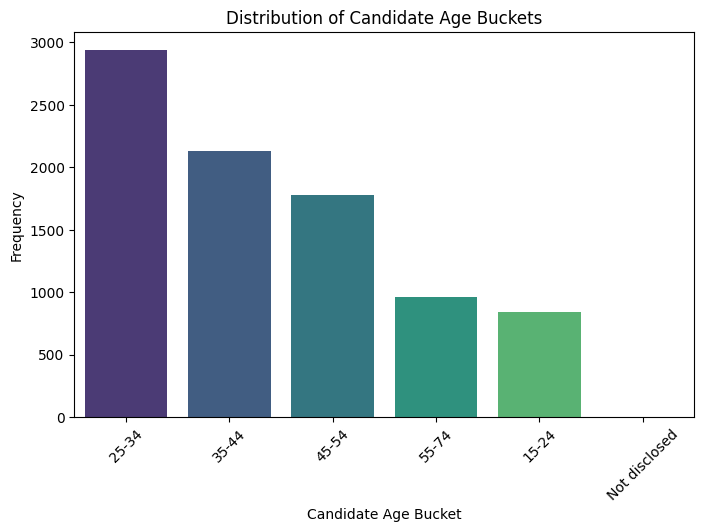

In [176]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the unique values
value_counts = dm_df['cand_age_bucket'].value_counts(dropna=False)  # Include NaN values

# Plot the frequency of each unique value
plt.figure(figsize=(8, 5))
sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")

# Add labels and title
plt.xlabel("Candidate Age Bucket")
plt.ylabel("Frequency")
plt.title("Distribution of Candidate Age Buckets")
plt.xticks(rotation=45)
plt.show()


From this plot we can check that the most applicants (in the 10 which are shown in the dataframe) belong to the 25-34 age bucket by a significant margin.

Now we can check the same thing for the most successful applicants in the dataframe containing only the highly ranked applicants.

C:\Users\annad\AppData\Local\Temp\ipykernel_38640\3643470564.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd

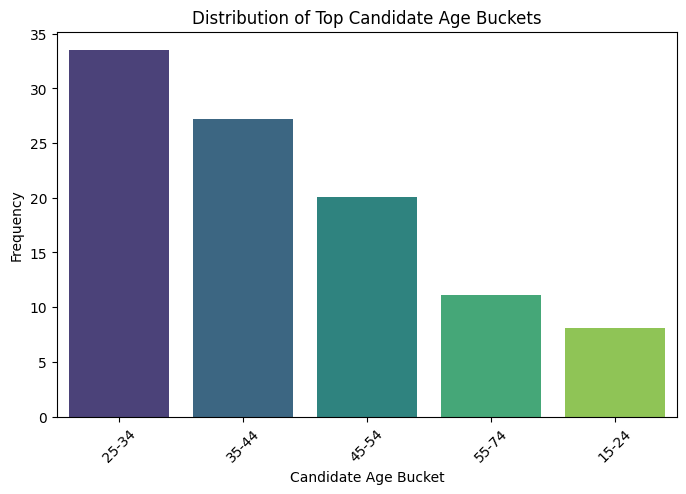

In [177]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the unique values
value_counts = dm_top_applicants['cand_age_bucket'].value_counts(normalize=True)*100

# Plot the frequency of each unique value
plt.figure(figsize=(8, 5))
sns.barplot(x=value_counts.index, y=value_counts.values, palette="viridis")

# Add labels and title
plt.xlabel("Candidate Age Bucket")
plt.ylabel("Frequency")
plt.title("Distribution of Top Candidate Age Buckets")
plt.xticks(rotation=45)
plt.show()


Also in this case, we notice that the 25-34 bucket looks to be the most successful one.

### 2.2 EDUCATION LEVEL

In [178]:
unique_values = dm_df['cand_education'].unique()
print("Unique values in cand_education column:", unique_values)

Unique values in cand_education column: ['Not disclosed' 'Degree / High School : Surveying'
 'Degree / High School : Scientific High School'
 'Degree / High School : Electrotechnical and Automation Technician'
 'Middle School'
 'Middle School;Degree / High School : Computer Science Technician'
 'Qualification / Certificate: Computer Systems Switchboard Operator;Degree / High School : Accountancy'
 'Degree / High School : Technician in Business Administration, Finance, and Marketing'
 'Qualification / Certificate: Mechanical Operator'
 "Bachelor's Degree : Nursing"
 'Qualification / Certificate: Health and Social Care Assistant (O.T.A.)'
 "Degree / High School : Scientific High School;Bachelor's Degree : Modern Languages and Cultures (L-11)"
 'Degree / High School : Business Economics'
 'Degree / High School : Social Services Technician'
 'Degree / High School : Maintenance and Technical Support Technician'
 "Bachelor's Degree : Physiotherapy"
 'Middle School;Degree / High School : High

The variety of this column is too great to bring insights, we could do a NLP task to divide the educations in more useful things like "Not disclosed", "Middle school", "High school", "Bachelor", "Master", "PhD", "other", but this is out of the scope of this project.

In [179]:
from collections import Counter
study_areas_counts = Counter(dm_df['cand_education'])

study_areas_counts_df = pd.DataFrame(study_areas_counts.items(), columns=['Education', 'Count'])
study_areas_counts_df = study_areas_counts_df.sort_values(by='Count', ascending=False)

study_areas_counts_df.head(10)

,Education,Count
0,Not disclosed,6305
4,Middle School,433
24,Degree / High School : Accountancy,116
39,Degree / High School : Technician in Electroni...,70
8,Qualification / Certificate: Mechanical Operator,47
2,Degree / High School : Scientific High School,47
12,Degree / High School : Business Economics,46
27,Degree / High School : Technician in Mechanica...,43
19,Higher Technical Institute (ITS) in Mechanical...,42
33,Qualification / Certificate: Electrical System...,39


This shows that most people choose to not disclose their education level, and this majority is extremely relevant.

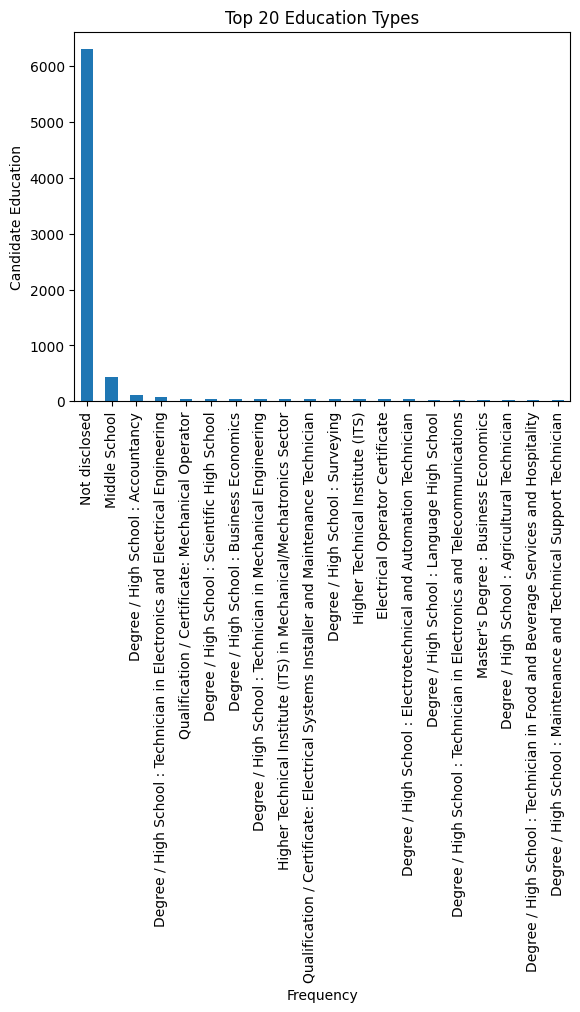

In [180]:
study_areas_counts_df.head(20).plot(x='Education', y='Count', kind='bar', legend=False)
plt.title('Top 20 Education Types')
plt.xlabel('Frequency')
plt.ylabel('Candidate Education')
plt.show()

Again, this shows that most people choose not to disclose their education type.

In [181]:
from collections import Counter
study_areas_counts = Counter(dm_top_applicants['cand_education'])

study_areas_counts_df = pd.DataFrame(study_areas_counts.items(), columns=['Education', 'Count'])
study_areas_counts_df = study_areas_counts_df.sort_values(by='Count', ascending=False)

study_areas_counts_df.head(10)

,Education,Count
0,Not disclosed,650
5,Middle School,42
22,Degree / High School : Accountancy,9
1,Degree / High School : Scientific High School,8
7,Higher Technical Institute (ITS) in Mechanical...,6
66,Degree / High School : Business Economics,4
39,Degree / High School : Language High School,4
44,Electrical Operator Certificate,4
20,Higher Technical Institute (ITS),4
62,Middle School;Elementary School Diploma;Degree...,4


Also in this case, the majority decides not to disclose their education level.

### 2.3 GENDER

In [182]:
unique_values = dm_df['cand_gender'].unique()
print("Unique values in cand_gender column:", unique_values)

Unique values in cand_gender column: ['Male' 'Female']


In [183]:
#assign Male colour to blue and female to pink for readability
custom_palette = ["#6495ED", "#FF69B4"]

In [184]:
# Count occurrences of each gender
gender_counts = dm_df['cand_gender'].value_counts(normalize=True) * 100  # Convert to percentage

# Print the percentage of each gender
print("Percentage distribution of candidate genders:\n", gender_counts)

# Find the gender that appears more frequently
most_frequent_gender = gender_counts.idxmax()  # Get the gender with the highest percentage
most_frequent_percentage = gender_counts.max()  # Get the highest percentage

print(f"\nThe gender '{most_frequent_gender}' appears the most, with {most_frequent_percentage:.2f}% of occurrences.")

Percentage distribution of candidate genders:
 cand_gender
Male      55.117382
Female    44.882618
Name: proportion, dtype: float64

The gender 'Male' appears the most, with 55.12% of occurrences.


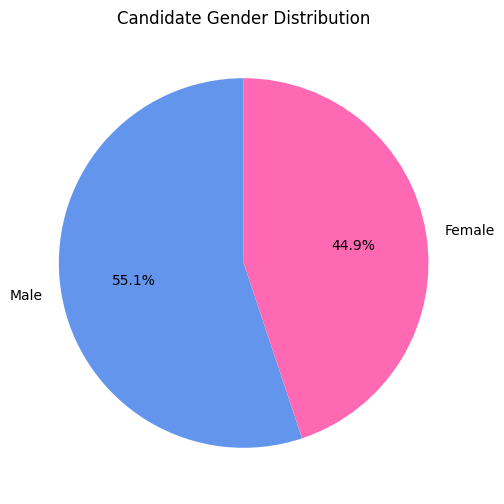

In [185]:
# Pie chart for gender distribution

plt.figure(figsize=(6, 6))
dm_df['cand_gender'].value_counts().plot.pie(autopct='%1.1f%%', colors=custom_palette, startangle=90)
plt.title("Candidate Gender Distribution")
plt.ylabel("")  # Hide y-label
plt.show()


We can see that there is a majority of Male candidates in the 10 selected, with a margin of 10.23%

The distribution is more or less maintained in all the positions od the ranking system.

In [186]:
# Count occurrences of each gender
gender_counts = dm_top_applicants['cand_gender'].value_counts(normalize=True) * 100  # Convert to percentage

# Print the percentage of each gender
print("Percentage distribution of candidate genders:\n", gender_counts)

# Find the gender that appears more frequently
most_frequent_gender = gender_counts.idxmax()  # Get the gender with the highest percentage
most_frequent_percentage = gender_counts.max()  # Get the highest percentage

print(f"\nThe gender '{most_frequent_gender}' appears the most, with {most_frequent_percentage:.2f}% of occurrences.")

Percentage distribution of candidate genders:
 cand_gender
Male      55.83815
Female    44.16185
Name: proportion, dtype: float64

The gender 'Male' appears the most, with 55.84% of occurrences.


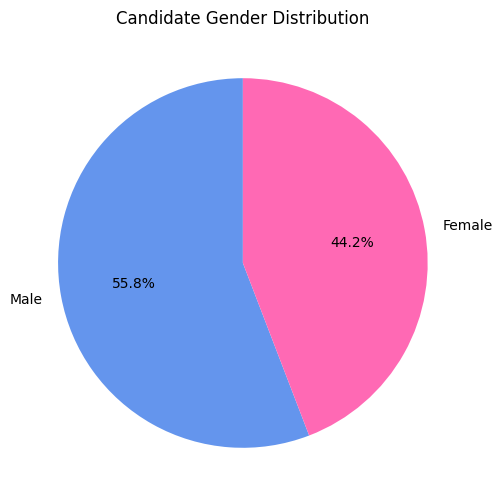

In [187]:

plt.figure(figsize=(6, 6))
dm_top_applicants['cand_gender'].value_counts().plot.pie(autopct='%1.1f%%', colors=custom_palette, startangle=90)
plt.title("Candidate Gender Distribution")
plt.ylabel("")  # Hide y-label
plt.show()


This margin is more or less maintained in the most successful applicant for each job description.

### 2.4 DOMICILE REGION

In [188]:
print(dm_df["cand_domicile_region"].unique())


['FRIULI VENEZIA GIULIA' 'LOMBARDIA' 'ABRUZZO' 'MOLISE' 'PIEMONTE'
 'VENETO' 'EMILIA ROMAGNA' 'CAMPANIA' "VALLE D'AOSTA" 'LAZIO'
 'TRENTINO ALTO ADIGE' 'SARDEGNA' 'TOSCANA' 'MARCHE' 'LIGURIA'
 'Not disclosed' 'PUGLIA' 'UMBRIA' 'CALABRIA']


In [189]:
unique_values = dm_df['cand_domicile_region'].unique()
print("Unique values in cand_domicile_region column:", unique_values)

Unique values in cand_domicile_region column: ['FRIULI VENEZIA GIULIA' 'LOMBARDIA' 'ABRUZZO' 'MOLISE' 'PIEMONTE'
 'VENETO' 'EMILIA ROMAGNA' 'CAMPANIA' "VALLE D'AOSTA" 'LAZIO'
 'TRENTINO ALTO ADIGE' 'SARDEGNA' 'TOSCANA' 'MARCHE' 'LIGURIA'
 'Not disclosed' 'PUGLIA' 'UMBRIA' 'CALABRIA']


In [190]:
# Count occurrences of each region in percentage
region_counts = dm_df['cand_domicile_region'].value_counts(normalize=True) * 100

# Print percentage distribution
print("Percentage distribution of domicile regions:\n", region_counts)


Percentage distribution of domicile regions:
 cand_domicile_region
LOMBARDIA                46.131606
EMILIA ROMAGNA           14.224587
VENETO                   14.051116
PIEMONTE                  9.378975
FRIULI VENEZIA GIULIA     4.244247
LAZIO                     3.723835
TOSCANA                   3.087776
TRENTINO ALTO ADIGE       1.607494
MARCHE                    1.457153
ABRUZZO                   0.844223
SARDEGNA                  0.358506
LIGURIA                   0.346941
VALLE D'AOSTA             0.231294
UMBRIA                    0.104082
MOLISE                    0.080953
Not disclosed             0.057824
CAMPANIA                  0.034694
PUGLIA                    0.023129
CALABRIA                  0.011565
Name: proportion, dtype: float64


C:\Users\annad\AppData\Local\Temp\ipykernel_38640\289213456.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_counts.index, y=region_counts.values, palette="viridis")
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(p

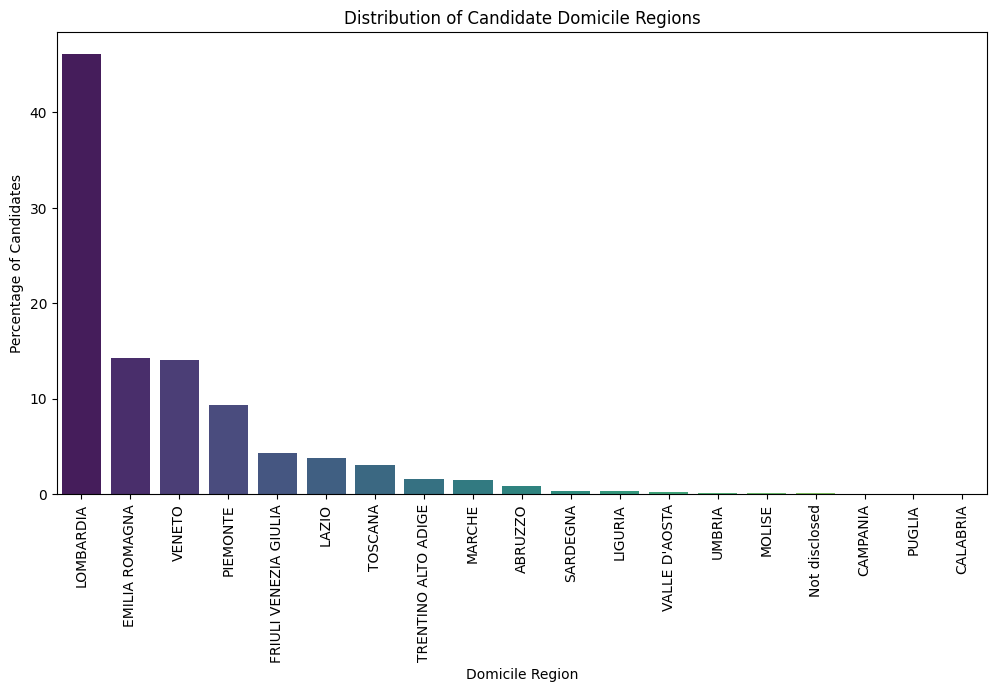

In [191]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the frequency of each domicile region
plt.figure(figsize=(12, 6))
sns.barplot(x=region_counts.index, y=region_counts.values, palette="viridis")

# Customize the plot
plt.xlabel("Domicile Region")
plt.ylabel("Percentage of Candidates")
plt.title("Distribution of Candidate Domicile Regions")
plt.xticks(rotation=90)  # Rotate for better readability
plt.show()


It is evident that the most top 10 candidates come from the LOMBARDIA region, by a huge margin. It is also noticeable that the southern regions of Italy have the least amount of applicants by a significant margin compared to the central and northern regions.

In [192]:
# Count occurrences of each region in percentage
top_region_counts = dm_top_applicants['cand_domicile_region'].value_counts(normalize=True) * 100

# Print percentage distribution
print("Percentage distribution of domicile regions:\n", top_region_counts)


Percentage distribution of domicile regions:
 cand_domicile_region
LOMBARDIA                46.011561
EMILIA ROMAGNA           13.988439
VENETO                   13.988439
PIEMONTE                  9.017341
FRIULI VENEZIA GIULIA     4.277457
LAZIO                     3.815029
TOSCANA                   3.815029
TRENTINO ALTO ADIGE       1.734104
MARCHE                    1.502890
ABRUZZO                   0.693642
LIGURIA                   0.462428
SARDEGNA                  0.346821
VALLE D'AOSTA             0.231214
UMBRIA                    0.115607
Name: proportion, dtype: float64


C:\Users\annad\AppData\Local\Temp\ipykernel_38640\3238706772.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_region_counts.index, y=top_region_counts.values, palette="viridis")
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.ge

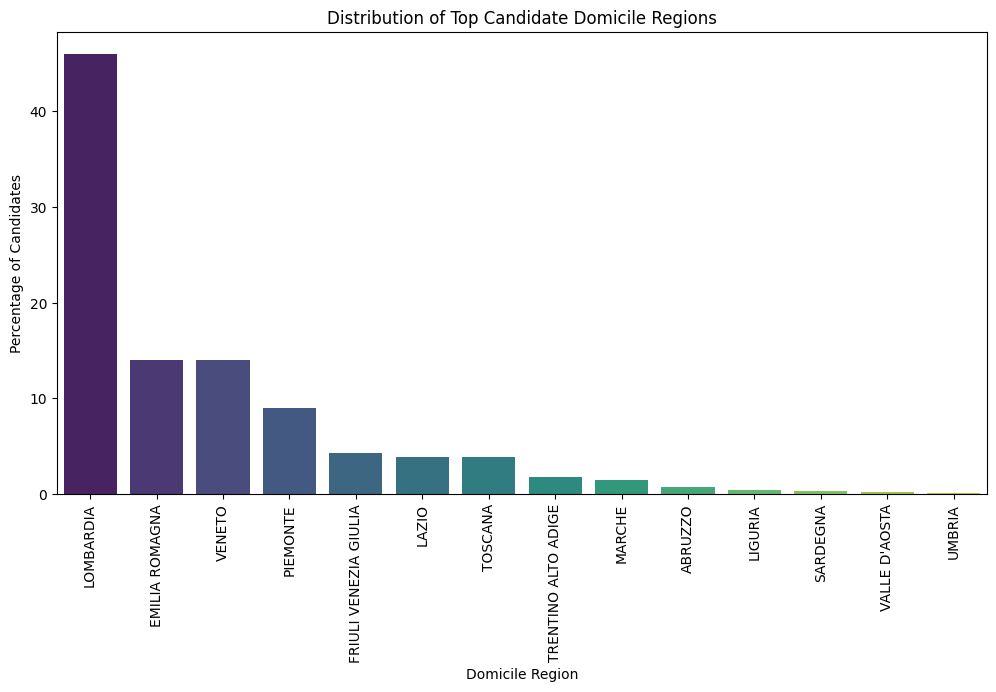

In [193]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the frequency of each domicile region
plt.figure(figsize=(12, 6))
sns.barplot(x=top_region_counts.index, y=top_region_counts.values, palette="viridis")

# Customize the plot
plt.xlabel("Domicile Region")
plt.ylabel("Percentage of Candidates")
plt.title("Distribution of Top Candidate Domicile Regions")
plt.xticks(rotation=90)
plt.show()

In the top applicants, the southern regions don't appear, indicating that no applicant from those was considered a successful candidate.

As expected, we can check the distribution of the candidate domicile region for each rank position (1-10) and this shows again a vast majority of Lombardia, followed by Veneto and Emilia Romagna.

### 2.5 DOMICILE PROVINCE

In [194]:
unique_values = dm_df['cand_domicile_province'].unique()
print("Unique values in cand_domicile_province column:", unique_values)

Unique values in cand_domicile_province column: ['UD' 'TS' 'GO' 'MI' 'MB' 'BG' 'CH' 'CB' 'BS' 'AL' 'VA' 'NO' 'VR' 'MN'
 'CO' 'PR' 'CR' 'PV' 'TO' 'PN' 'PC' 'BL' 'MO' 'BO' 'LC' 'LO' 'BI' 'VC'
 'CN' 'AT' 'PD' 'TV' 'VE' 'RE' 'RO' 'Not disclosed' 'VI' 'AO' 'RM' 'FR'
 'LT' 'RI' 'FE' 'TN' 'CA' 'PE' 'PO' 'FC' 'AQ' 'FM' 'MC' 'GE' 'SC' 'BT'
 'FI' 'PI' 'LI' 'LU' 'PT' 'AN' 'SI' 'MS' 'PU' 'AP' 'TE' 'RN' 'RA' 'SV'
 'BZ' 'AR' 'SO' 'VT' 'IS' 'PG' 'CS' 'IM' 'OR' 'NU' 'SU' 'CE']


In [195]:
# Count occurrences of each region in percentage
province_counts = dm_df['cand_domicile_province'].value_counts(normalize=True) * 100

# Print percentage distribution
print("Percentage distribution of domicile provinces:\n", province_counts)


Percentage distribution of domicile provinces:
 cand_domicile_province
MI    15.508269
BG    10.142246
BS     8.696658
TO     5.851740
BO     5.539493
        ...    
IS     0.023129
MS     0.011565
CS     0.011565
VT     0.011565
CE     0.011565
Name: proportion, Length: 80, dtype: float64


C:\Users\annad\AppData\Local\Temp\ipykernel_38640\2683706760.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=province_counts.index, y=province_counts.values, palette="viridis")
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_gr

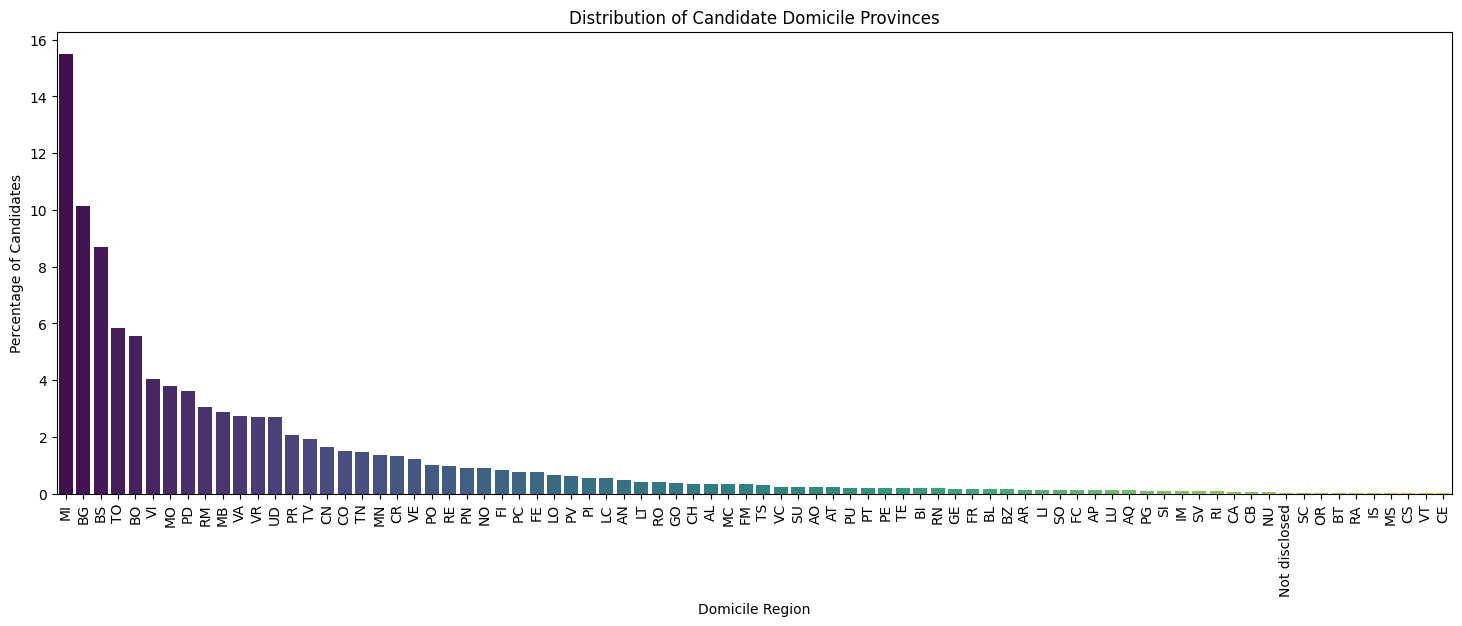

In [196]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the frequency of each domicile region
plt.figure(figsize=(18, 6))
sns.barplot(x=province_counts.index, y=province_counts.values, palette="viridis")

# Customize the plot
plt.xlabel("Domicile Region")
plt.ylabel("Percentage of Candidates")
plt.title("Distribution of Candidate Domicile Provinces")
plt.xticks(rotation=90)  # Rotate for better readability
plt.show()


Most candidates come from the three main Lombardy provinces: Milano, Bergamo and Brescia. This is in line with the observations made before.

Now we can check the same thing for the top applicants

In [197]:
# Count occurrences of each region in percentage
province_counts = dm_top_applicants['cand_domicile_province'].value_counts(normalize=True) * 100

# Print percentage distribution
print("Percentage distribution of domicile provinces:\n", province_counts)


Percentage distribution of domicile provinces:
 cand_domicile_province
MI    15.260116
BS     9.595376
BG     9.595376
TO     5.433526
BO     5.202312
        ...    
OR     0.115607
CH     0.115607
TE     0.115607
IM     0.115607
BZ     0.115607
Name: proportion, Length: 61, dtype: float64


C:\Users\annad\AppData\Local\Temp\ipykernel_38640\2683706760.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=province_counts.index, y=province_counts.values, palette="viridis")
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_gr

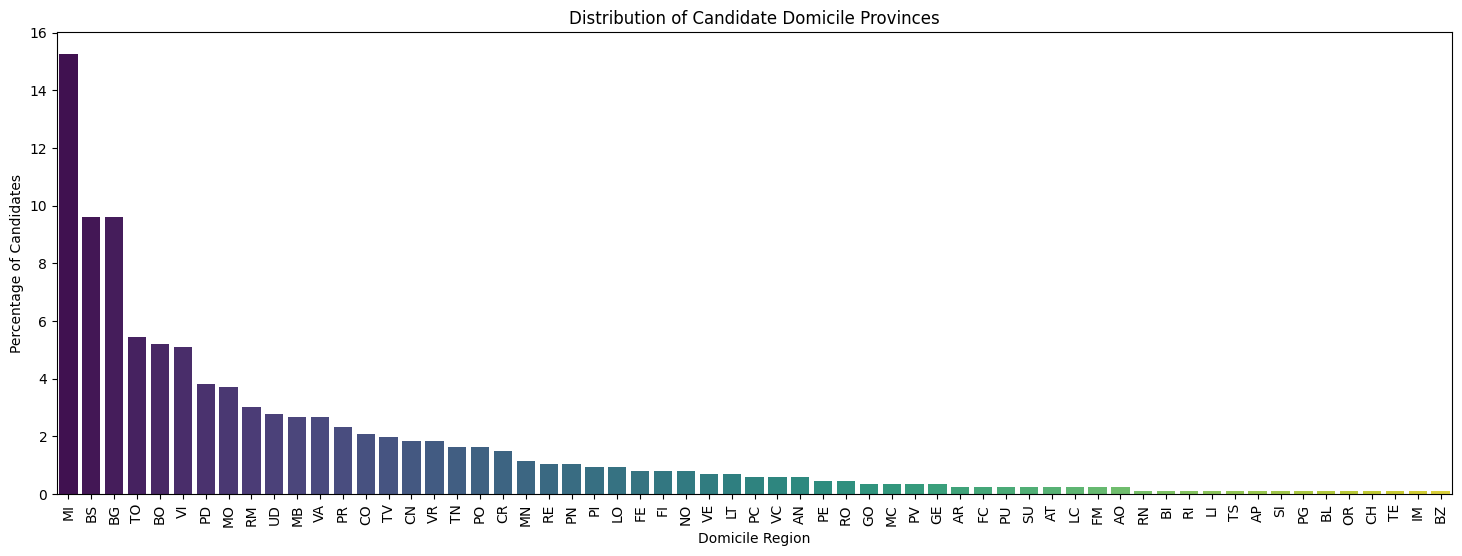

In [198]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the frequency of each domicile region
plt.figure(figsize=(18, 6))
sns.barplot(x=province_counts.index, y=province_counts.values, palette="viridis")

# Customize the plot
plt.xlabel("Domicile Region")
plt.ylabel("Percentage of Candidates")
plt.title("Distribution of Candidate Domicile Provinces")
plt.xticks(rotation=90)  # Rotate for better readability
plt.show()


Checking the match between the domicile province and the job work province. This is useful as it will help show wether there is a privileged selection of people coming from the same province as the location of the job.

In [199]:
# List unique values in both columns to spot inconsistencies
print("Candidate Domicile Provinces:", dm_df['cand_domicile_province'].unique())
print("Job Work Provinces:", dm_df['job_work_province'].unique())

Candidate Domicile Provinces: ['UD' 'TS' 'GO' 'MI' 'MB' 'BG' 'CH' 'CB' 'BS' 'AL' 'VA' 'NO' 'VR' 'MN'
 'CO' 'PR' 'CR' 'PV' 'TO' 'PN' 'PC' 'BL' 'MO' 'BO' 'LC' 'LO' 'BI' 'VC'
 'CN' 'AT' 'PD' 'TV' 'VE' 'RE' 'RO' 'Not disclosed' 'VI' 'AO' 'RM' 'FR'
 'LT' 'RI' 'FE' 'TN' 'CA' 'PE' 'PO' 'FC' 'AQ' 'FM' 'MC' 'GE' 'SC' 'BT'
 'FI' 'PI' 'LI' 'LU' 'PT' 'AN' 'SI' 'MS' 'PU' 'AP' 'TE' 'RN' 'RA' 'SV'
 'BZ' 'AR' 'SO' 'VT' 'IS' 'PG' 'CS' 'IM' 'OR' 'NU' 'SU' 'CE']
Job Work Provinces: ['UD ' 'MI ' 'CH ' 'BS ' 'VA ' 'PR ' 'GO ' 'CN ' 'BG ' 'TV ' 'TO ' 'MN '
 'VR ' 'AO ' 'RM ' 'FR ' 'MO ' 'PD ' 'RE ' 'BO ' 'VI ' 'MB ' 'CO ' 'LC '
 'FM ' 'PC ' 'VE ' 'CR ' 'TN ' 'LO ' 'PI ' 'FI ' 'MC ' 'PV ' 'FC ' 'RO '
 'GE ' 'AR ' 'PN ' 'PU ' 'TE ' 'AQ ' 'BI ' 'AN ' 'SI ' 'PG ' 'BL ' 'NU '
 'CA ' 'SO ' 'AP ' 'NO ' 'BZ ']


In [200]:
# Remove leading and trailing whitespace from both columns
dm_df['cand_domicile_province'] = dm_df['cand_domicile_province'].str.strip()
dm_df['job_work_province'] = dm_df['job_work_province'].str.strip()

# Now perform the comparison
dm_df['match'] = dm_df['cand_domicile_province'] == dm_df['job_work_province']

# Calculate percentages
match_percentage = dm_df['match'].mean() * 100
mismatch_percentage = 100 - match_percentage

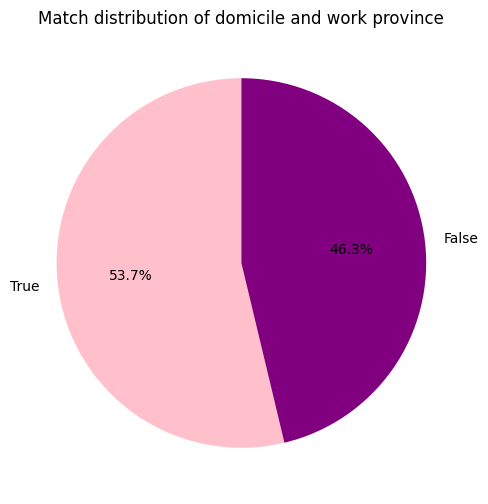

In [201]:
plt.figure(figsize=(6, 6))
dm_df['match'].value_counts().plot.pie(autopct='%1.1f%%', colors=['pink', 'purple'], startangle=90)
plt.title("Match distribution of domicile and work province")
plt.ylabel("")  # Hide y-label
plt.show()

The top 10 applicants reside most likely in the province where the job is located, although the margin is not big.


Does the same thing apply for the top applicant for each job?

In [202]:
# Create an independent copy to avoid modifying the original DataFrame
dm_top_applicants = dm_top_applicants.copy()

# Remove leading and trailing whitespace from both columns
dm_top_applicants['cand_domicile_province'] = dm_top_applicants['cand_domicile_province'].str.strip()
dm_top_applicants['job_work_province'] = dm_top_applicants['job_work_province'].str.strip()

# Now perform the comparison
dm_top_applicants['match'] = dm_top_applicants['cand_domicile_province'] == dm_top_applicants['job_work_province']

# Calculate percentages
match_percentage_top = dm_top_applicants['match'].mean() * 100
mismatch_percentage_top = 100 - match_percentage_top

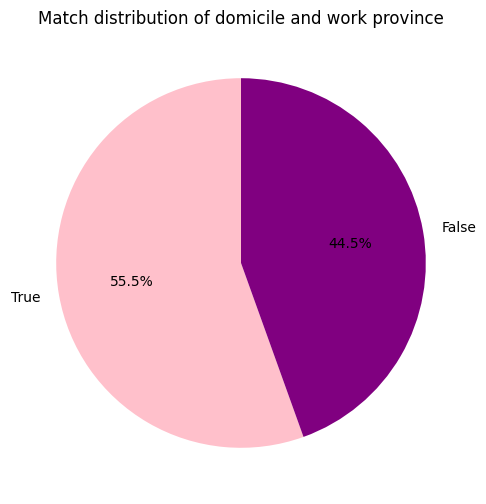

In [203]:
plt.figure(figsize=(6, 6))
dm_top_applicants['match'].value_counts().plot.pie(autopct='%1.1f%%', colors=['pink', 'purple'], startangle=90)
plt.title("Match distribution of domicile and work province")
plt.ylabel("")  # Hide y-label
plt.show()

Also in this case there is a predominance of people's job province and the location of the job matching. The margin is only slightly bigger than the top 10 candidates dataframe, showing a phenomenon similar to the gender situation.

### 2.6 JOB SECTOR

C:\Users\annad\AppData\Local\Temp\ipykernel_38640\3889264393.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=job_sector_counts.index, y=job_sector_counts.values, palette="viridis")
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.ge

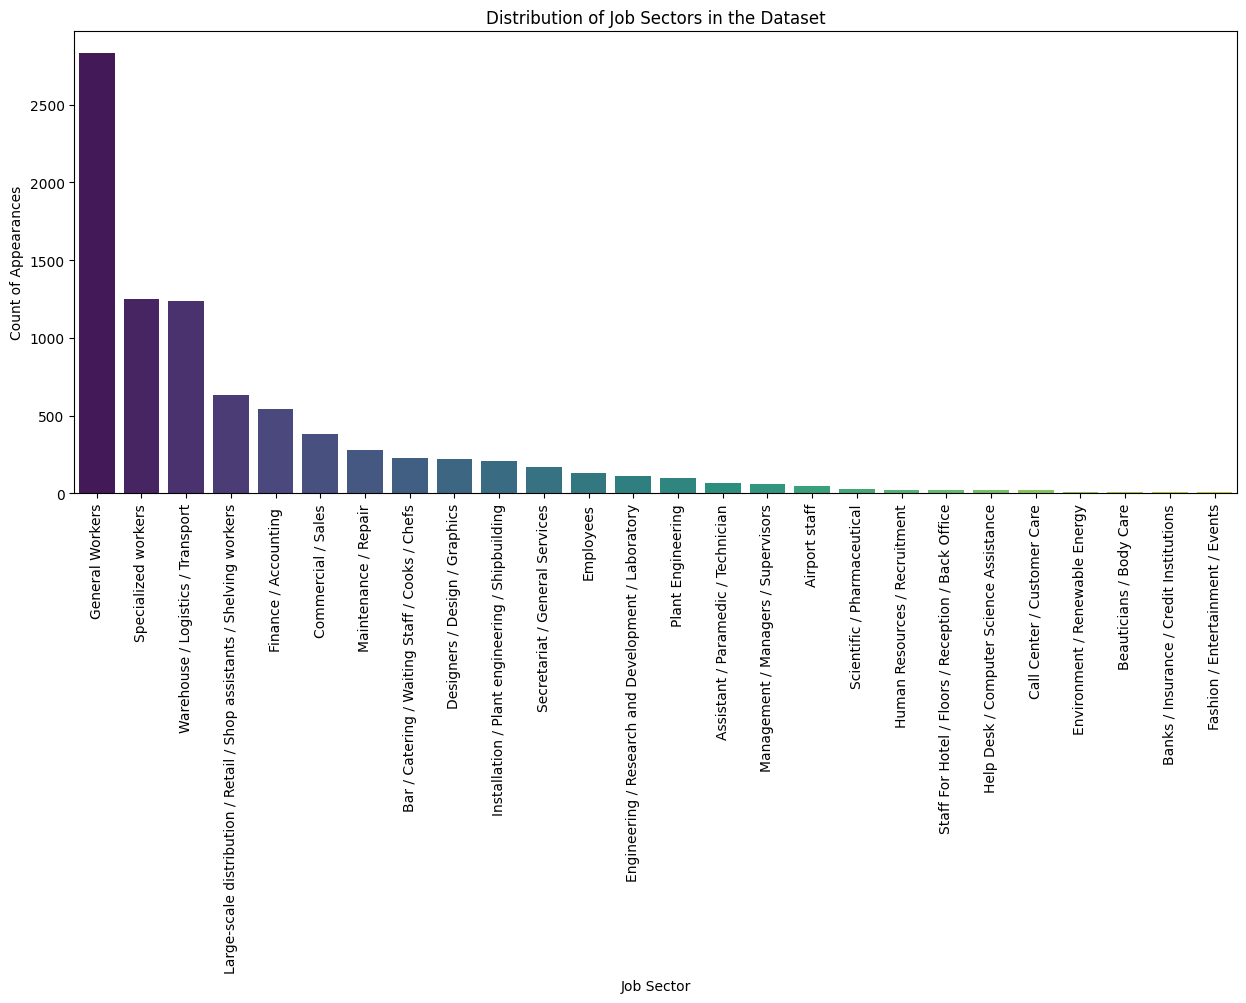

In [204]:
# Count occurrences of each job sector
job_sector_counts = dm_df['job_sector'].value_counts()

# Plot the distribution
plt.figure(figsize=(15, 6))
sns.barplot(x=job_sector_counts.index, y=job_sector_counts.values, palette="viridis")

# Customize the plot
plt.xlabel("Job Sector")
plt.ylabel("Count of Appearances")
plt.title("Distribution of Job Sectors in the Dataset")
plt.xticks(rotation=90)  # Rotate labels for better readability
plt.show()

This adds insights as we can tell which are the most sought-after job sectors in the dataframe:
- General workers (vast majority)
- Specialized workers
- Warehouse, logistics, transport

C:\Users\annad\AppData\Local\Temp\ipykernel_38640\1125682173.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=job_sector_counts.index, y=job_sector_counts.values, palette="viridis")
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.ge

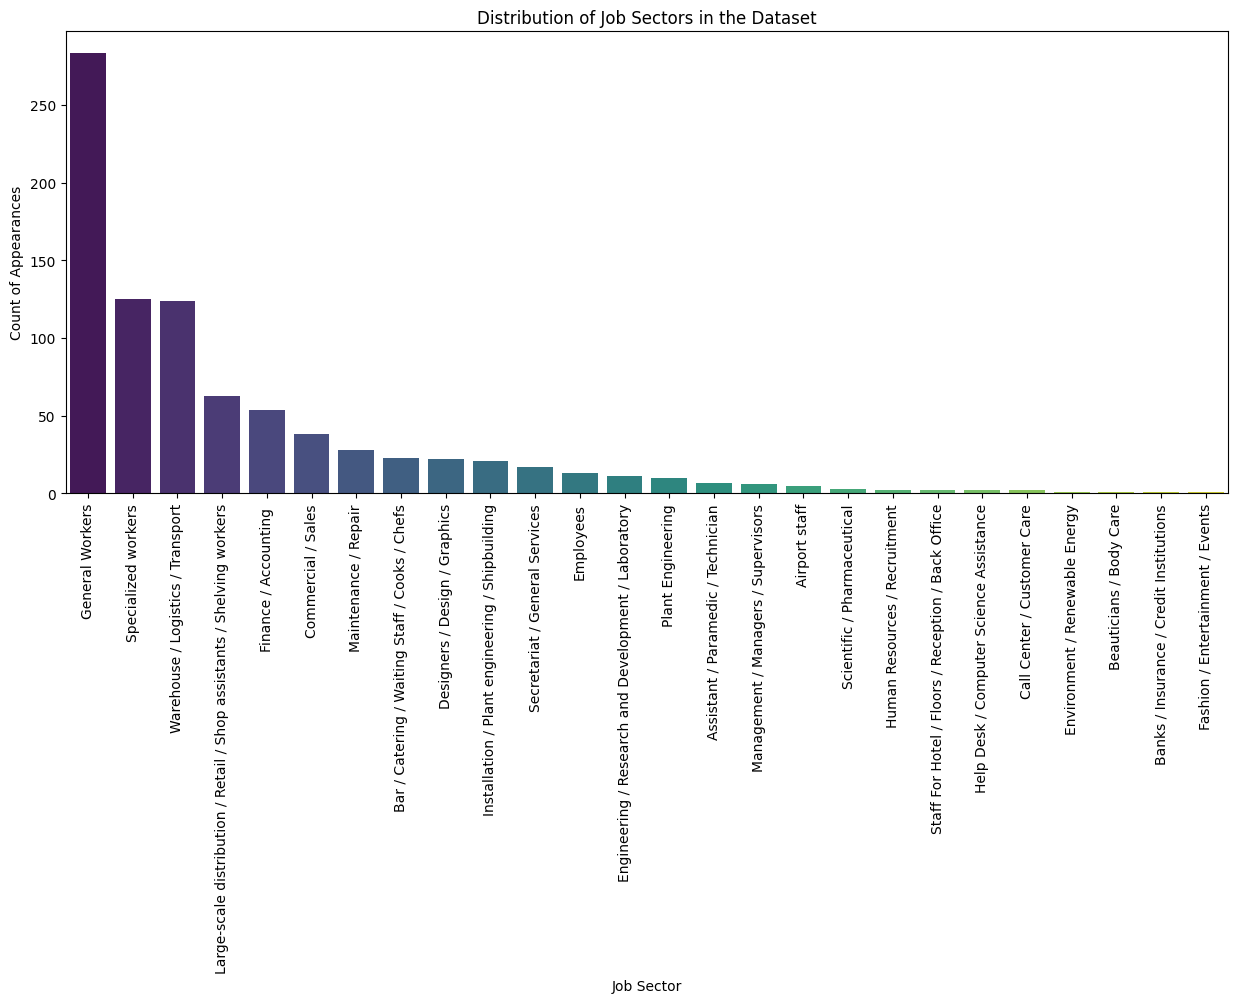

In [205]:
# Count occurrences of each job sector
job_sector_counts = dm_top_applicants['job_sector'].value_counts()

# Plot the distribution
plt.figure(figsize=(15, 6))
sns.barplot(x=job_sector_counts.index, y=job_sector_counts.values, palette="viridis")

# Customize the plot
plt.xlabel("Job Sector")
plt.ylabel("Count of Appearances")
plt.title("Distribution of Job Sectors in the Dataset")
plt.xticks(rotation=90)  # Rotate labels for better readability
plt.show()

The same distribution is maintained when considering the top applicants dataframe.

### 2.7 JOB CONTRACT TYPE

In [206]:
dm_df.head()

,cand_id,job_id,distance_km,match_score,match_rank,cand_gender,cand_age_bucket,cand_domicile_province,cand_domicile_region,cand_education,job_contract_type,job_professional_category,job_sector,job_work_province,match
0,"5,664,912",OFF_1011_1427,32.327042,99.573387,1,Male,45-54,UD,FRIULI VENEZIA GIULIA,Not disclosed,Subordinate employment,Surveying and technician of civil and industri...,Designers / Design / Graphics,UD,True
1,"4,999,120",OFF_1011_1427,15.595593,99.210564,2,Male,35-44,UD,FRIULI VENEZIA GIULIA,Not disclosed,Subordinate employment,Surveying and technician of civil and industri...,Designers / Design / Graphics,UD,True
2,"5,413,671",OFF_1011_1427,31.348877,99.118614,3,Female,45-54,UD,FRIULI VENEZIA GIULIA,Not disclosed,Subordinate employment,Surveying and technician of civil and industri...,Designers / Design / Graphics,UD,True
3,"5,965,090",OFF_1011_1427,66.315598,97.409767,4,Male,15-24,TS,FRIULI VENEZIA GIULIA,Not disclosed,Subordinate employment,Surveying and technician of civil and industri...,Designers / Design / Graphics,UD,False
4,"5,771,219",OFF_1011_1427,15.595593,97.323875,5,Female,35-44,UD,FRIULI VENEZIA GIULIA,Not disclosed,Subordinate employment,Surveying and technician of civil and industri...,Designers / Design / Graphics,UD,True


C:\Users\annad\AppData\Local\Temp\ipykernel_38640\3540179711.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=job_contract_counts.index, y=job_contract_counts.values, palette="viridis")
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_dat

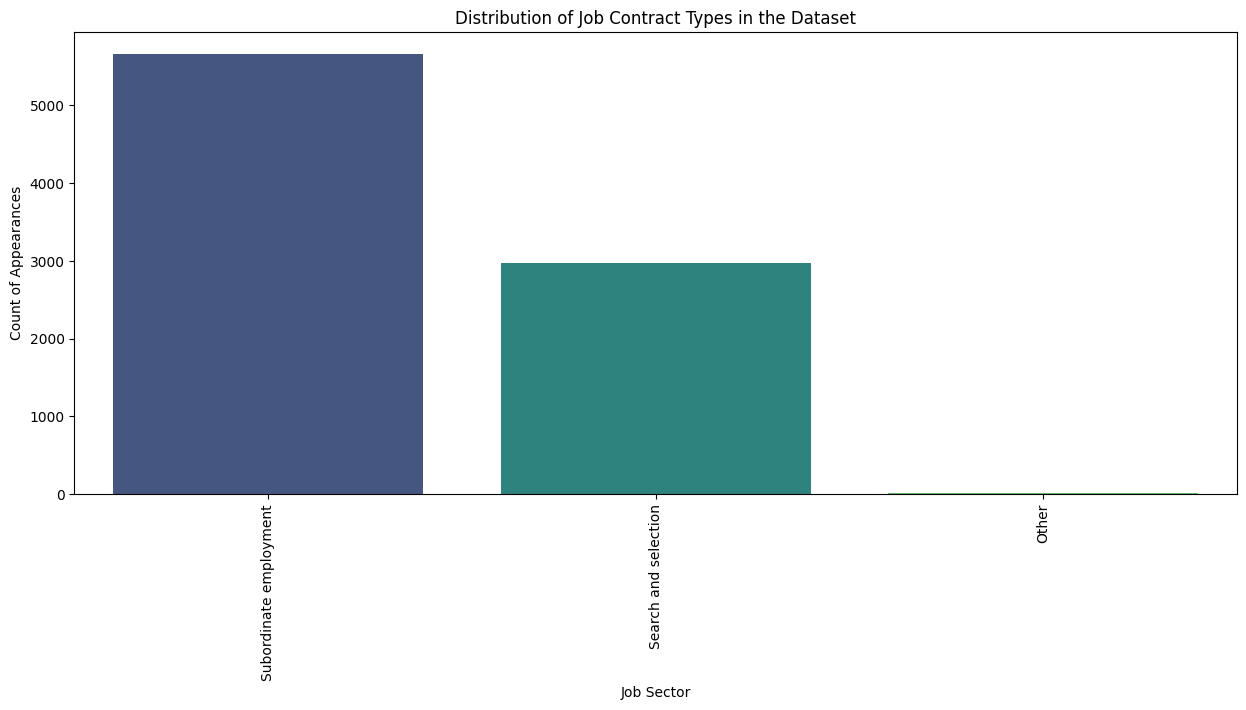

In [207]:
# Count occurrences of each job sector
job_contract_counts = dm_df['job_contract_type'].value_counts()

# Plot the distribution
plt.figure(figsize=(15, 6))
sns.barplot(x=job_contract_counts.index, y=job_contract_counts.values, palette="viridis")

# Customize the plot
plt.xlabel("Job Sector")
plt.ylabel("Count of Appearances")
plt.title("Distribution of Job Contract Types in the Dataset")
plt.xticks(rotation=90)
plt.show()

This plot shows the frequency with wich the vatious contract types appear in the dataframe.

## 3. TWO FEATURE EXPLORATION

### Distribution of Candidate Age Bucket across the ranks

c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.g

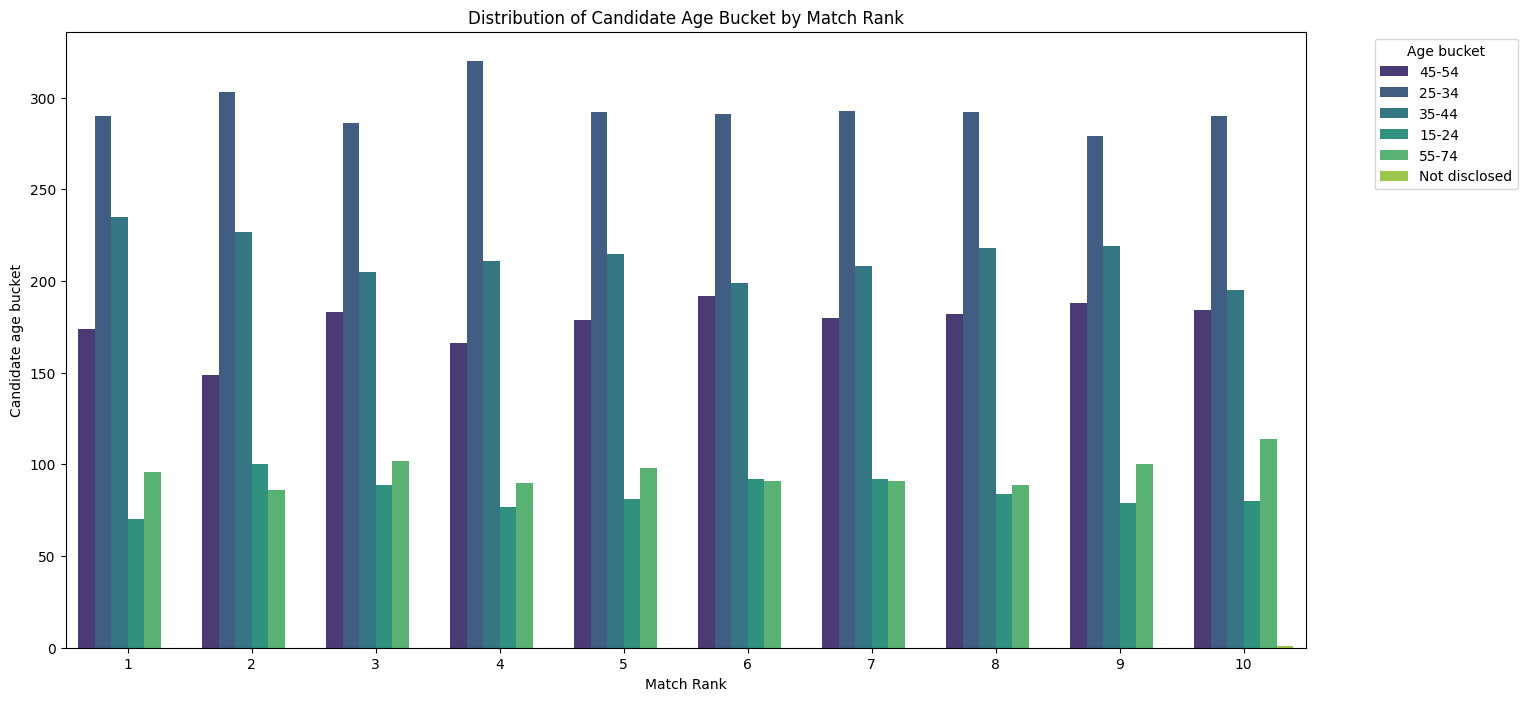

In [208]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 8))

# Plot the frequency of each domicile region for different match ranks
sns.countplot(data=dm_df, x="match_rank", hue="cand_age_bucket", palette='viridis')

# Customize the plot
plt.xlabel("Match Rank")
plt.ylabel("Candidate age bucket")
plt.title("Distribution of Candidate Age Bucket by Match Rank")
plt.legend(title="Age bucket", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)  # Ensure readability

plt.show()


### Distribution of Gender across all rank positions

c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


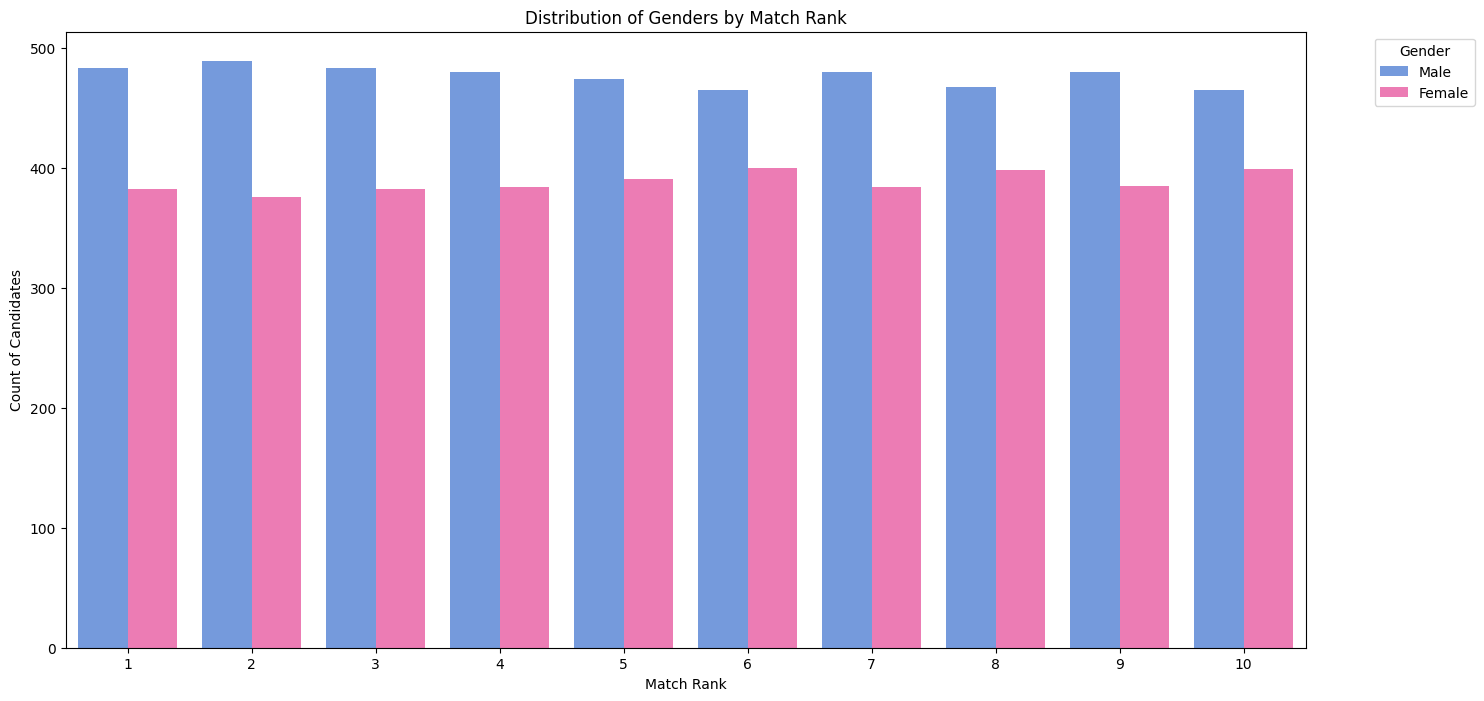

In [209]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 8))

# Plot the frequency of each domicile region for different match ranks
sns.countplot(data=dm_df, x="match_rank", hue="cand_gender", palette=custom_palette)

# Customize the plot
plt.xlabel("Match Rank")
plt.ylabel("Count of Candidates")
plt.title("Distribution of Genders by Match Rank")
plt.legend(title="Gender", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)  # Ensure readability

plt.show()


### Gender Distribution inside each job sector

In [210]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count occurrences of each gender per job sector
gender_counts = dm_df.groupby(["job_sector", "cand_gender"]).size().reset_index(name="count")

# Convert counts to percentages within each job sector (reset index to avoid alignment issues)
gender_counts["percentage"] = (
    gender_counts.groupby("job_sector")["count"]
    .apply(lambda x: x / x.sum() * 100).round(2)
    .reset_index(drop=True)  # 🔹 Ensure proper index alignment
)

# Print percentages
print("Gender Distribution by Job Sector (%):")
for sector in gender_counts["job_sector"].unique():
    sector_data = gender_counts[gender_counts["job_sector"] == sector]
    percentages = {row["cand_gender"]: row["percentage"] for _, row in sector_data.iterrows()}
    print(f"{sector}: {percentages}")

Gender Distribution by Job Sector (%):
Airport staff: {'Female': 60.0, 'Male': 40.0}
Assistant / Paramedic / Technician: {'Female': 77.14, 'Male': 22.86}
Banks / Insurance / Credit Institutions: {'Female': 50.0, 'Male': 50.0}
Bar / Catering / Waiting Staff / Cooks / Chefs: {'Female': 60.0, 'Male': 40.0}
Beauticians / Body Care: {'Female': 90.0, 'Male': 10.0}
Call Center / Customer Care: {'Female': 55.0, 'Male': 45.0}
Commercial / Sales: {'Female': 76.58, 'Male': 23.42}
Designers / Design / Graphics: {'Female': 40.0, 'Male': 60.0}
Employees: {'Female': 46.92, 'Male': 53.08}
Engineering / Research and Development / Laboratory: {'Female': 46.36, 'Male': 53.64}
Environment / Renewable Energy: {'Female': 60.0, 'Male': 40.0}
Fashion / Entertainment / Events: {'Female': 80.0, 'Male': 20.0}
Finance / Accounting : {'Female': 74.07, 'Male': 25.93}
General Workers: {'Female': 39.66, 'Male': 60.34}
Help Desk / Computer Science Assistance: {'Female': 60.0, 'Male': 40.0}
Human Resources / Recruitmen

c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


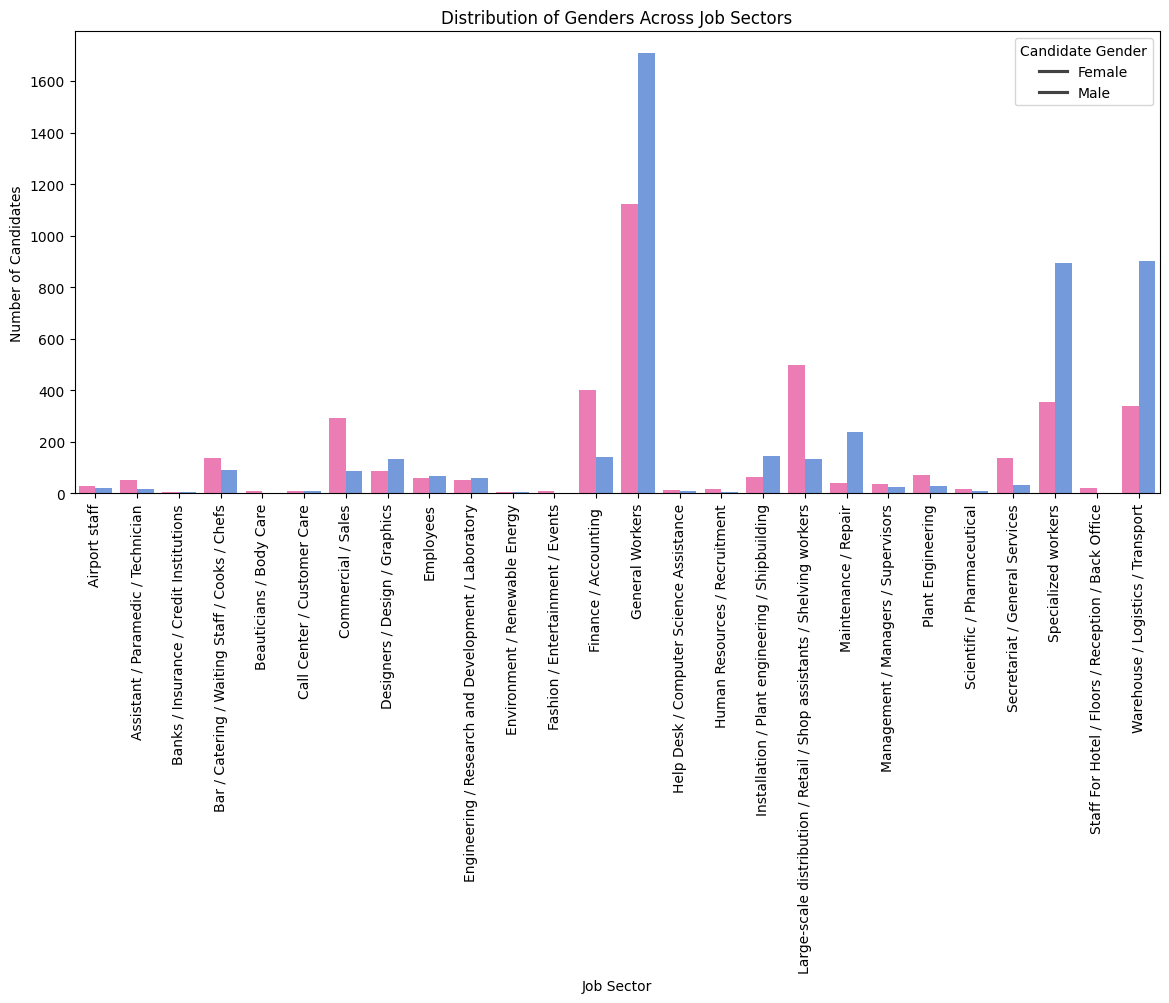

In [211]:
import seaborn as sns
import matplotlib.pyplot as plt

gender_palette = {"Female": "#FF69B4", "Male": "#6495ED"}

# Count occurrences of each gender per job sector
gender_counts = dm_df.groupby(["job_sector", "cand_gender"]).size().reset_index(name="count")

# Plot grouped bar chart
plt.figure(figsize=(14, 6))
sns.barplot(x="job_sector", y="count", hue="cand_gender", data=gender_counts, palette=gender_palette)

# Customize the plot
plt.xlabel("Job Sector")
plt.ylabel("Number of Candidates")
plt.title("Distribution of Genders Across Job Sectors")
plt.xticks(rotation=90)  # Rotate sector names for readability
plt.legend(title="Candidate Gender", labels=["Female", "Male"])
plt.show()



Not in all the fields we observe a drastic majority, and it is also important to say that not all fields are equally represented in the dataframe (more on this in the section detailing the job_sector distribution). Still, we tend to observe that women tend to be more represented in fields such as Staff For *Hotel / Floors / Reception / Back Office* which is 100% Female, or *Beauticians / Body Care* which is 90% Female, as well as *Secretariat / General Services*, *Fashion / Entertainment / Events*, *Human Resources / Recruitment* and *Large-scale distribution / Retail / Shop assistants / Shelving workers*, which all range at around 80% female dominance. While male dominated fields are not as harsh (we never have distributions that reach 90% as in the female dominated fields), but some examples are *Maintenance / Repair* (85% male) and *Warehouse / Logistics / Transport* (72% male).


Even after noticing this, if we go back to the analysis of the frequency of the job sectors, we can see that the female-dominated ones are not as frequent in the dataframe, which could mean that there are not as many opportunities for women as there are for men.

### Distribution of Job Offer Types by Gender

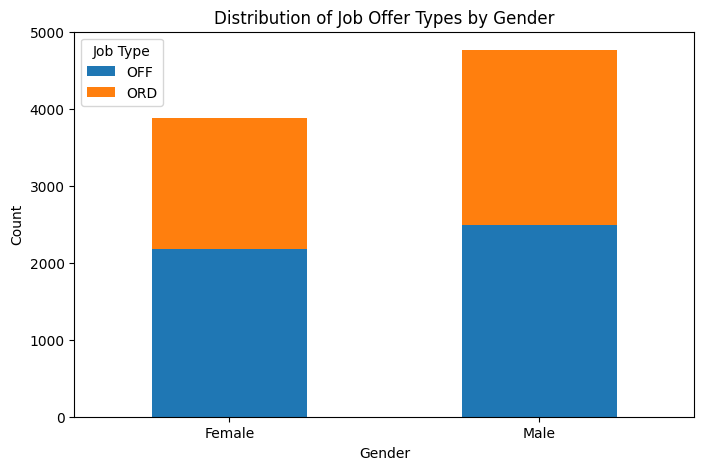

In [212]:
# Extract job type prefix
dm_df["job_type"] = dm_df["job_id"].apply(lambda x: "OFF" if x.startswith("OFF_") else ("ORD" if x.startswith("ORD_") else None))

# Count occurrences per gender and job type
job_counts = dm_df.groupby(["cand_gender", "job_type"]).size().unstack(fill_value=0)

custom_palette = ["#FF69B4", "#6495ED"]
job_counts.plot(kind="bar", stacked=True, figsize=(8, 5))
plt.title("Distribution of Job Offer Types by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Job Type")
plt.show()

### Distribution of Candidate Domicile Regions by Match Rank

c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.g

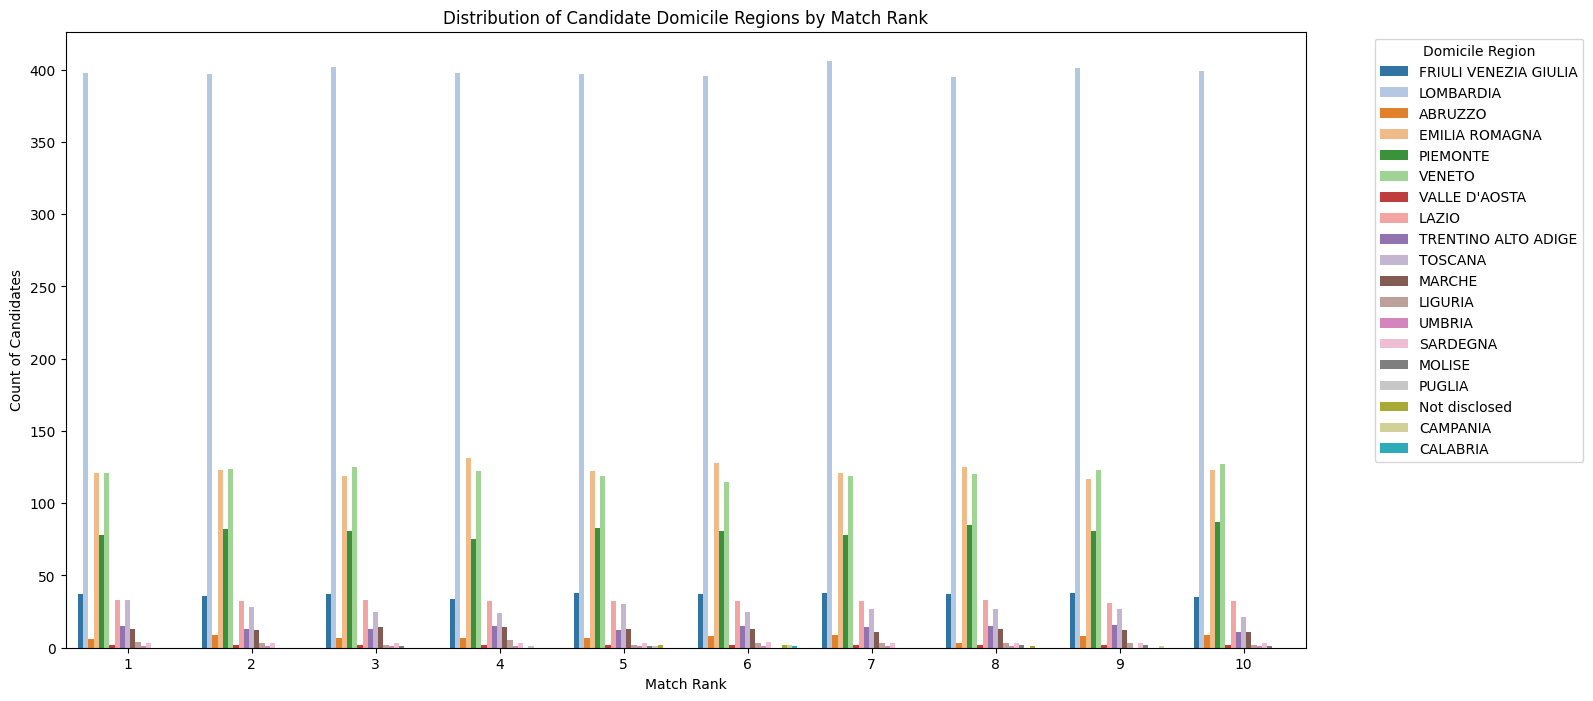

In [213]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 8))

# Plot the frequency of each domicile region for different match ranks
sns.countplot(data=dm_df, x="match_rank", hue="cand_domicile_region", palette="tab20")

# Customize the plot
plt.xlabel("Match Rank")
plt.ylabel("Count of Candidates")
plt.title("Distribution of Candidate Domicile Regions by Match Rank")
plt.legend(title="Domicile Region", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)  # Ensure readability

plt.show()


### Gender distribution inside contract types

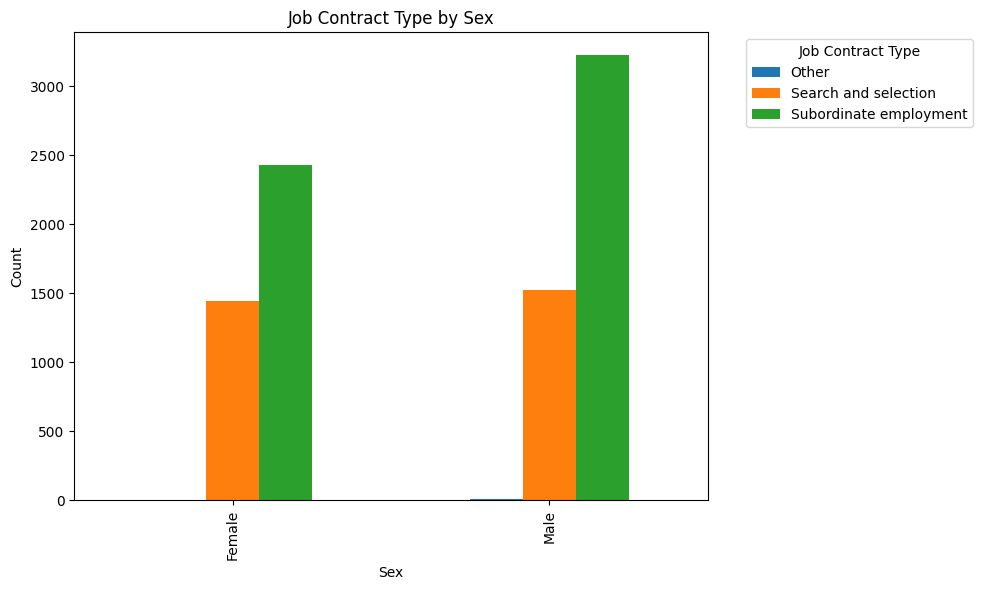

In [214]:
pivot = dm_df.pivot_table(index='cand_gender', columns='job_contract_type', aggfunc='size', fill_value=0)

pivot.plot(kind='bar', figsize=(10, 6))
plt.title('Job Contract Type by Sex')
plt.ylabel('Count')
plt.xlabel('Sex')
plt.legend(title='Job Contract Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Age distribution in contract types

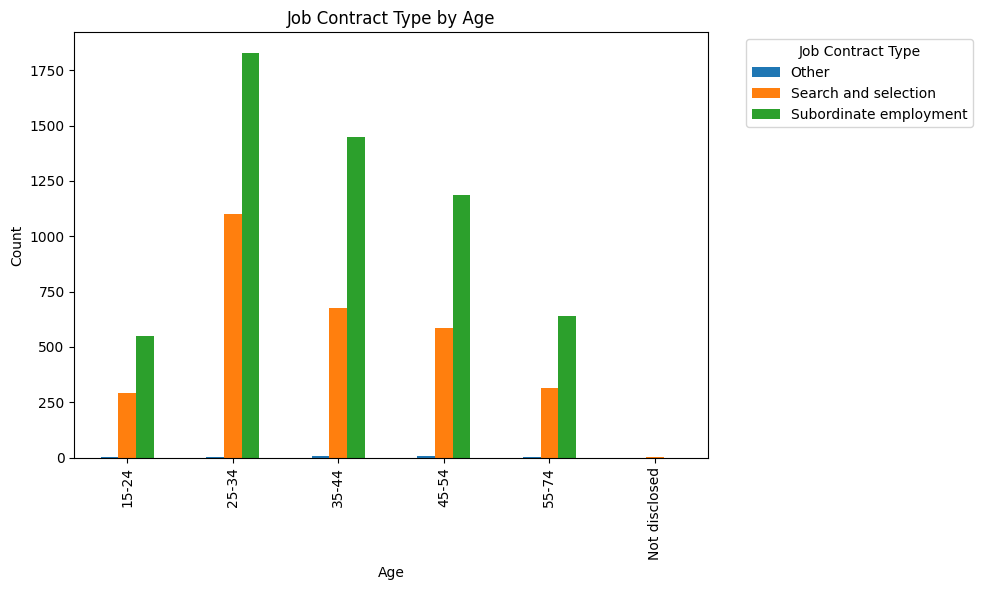

In [215]:
pivot = dm_df.pivot_table(index='cand_age_bucket', columns='job_contract_type', aggfunc='size', fill_value=0)

pivot.plot(kind='bar', figsize=(10, 6))
plt.title('Job Contract Type by Age')
plt.ylabel('Count')
plt.xlabel('Age')
plt.legend(title='Job Contract Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 4. CORRELATION BETWEEN VARIABLES

In order to perform this task the dtaframe needs to have all (or most) numerical values instead of relational. We will create dm_df_encoded in order to do this.

In [216]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Create a copy of dm_df to store the encoded values
#dm_df_encoded = dm_df.copy()

In [217]:
dm_df.dtypes

cand_id                       object
job_id                        object
distance_km                  float64
match_score                  float64
match_rank                     int64
cand_gender                   object
cand_age_bucket               object
cand_domicile_province        object
cand_domicile_region          object
cand_education                object
job_contract_type             object
job_professional_category     object
job_sector                    object
job_work_province             object
match                           bool
job_type                      object
dtype: object

In [218]:
categorical_cols = [
'cand_gender',
'cand_age_bucket',
'cand_domicile_province',
'cand_domicile_region',
'cand_education',
'job_contract_type',
'job_professional_category',
'job_sector',
'job_work_province',
'match'
]

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    dm_df[col] = le.fit_transform(dm_df[col])
    label_encoders[col] = le



In [219]:
dm_df.head()

,cand_id,job_id,distance_km,match_score,match_rank,cand_gender,cand_age_bucket,cand_domicile_province,cand_domicile_region,cand_education,job_contract_type,job_professional_category,job_sector,job_work_province,match,job_type
0,"5,664,912",OFF_1011_1427,32.327042,99.573387,1,1,3,73,4,327,2,166,7,48,1,OFF
1,"4,999,120",OFF_1011_1427,15.595593,99.210564,2,1,2,73,4,327,2,166,7,48,1,OFF
2,"5,413,671",OFF_1011_1427,31.348877,99.118614,3,0,3,73,4,327,2,166,7,48,1,OFF
3,"5,965,090",OFF_1011_1427,66.315598,97.409767,4,1,0,71,4,327,2,166,7,48,0,OFF
4,"5,771,219",OFF_1011_1427,15.595593,97.323875,5,0,2,73,4,327,2,166,7,48,1,OFF


In [220]:
# #dm_df_correlation = dm_df_encoded.copy()
# dm_df.drop('cand_id', axis=1, inplace=True)
# dm_df.drop('job_id', axis=1, inplace=True)
# dm_df.drop('job_type', axis=1, inplace=True)

In [221]:
dm_df.head()

,cand_id,job_id,distance_km,match_score,match_rank,cand_gender,cand_age_bucket,cand_domicile_province,cand_domicile_region,cand_education,job_contract_type,job_professional_category,job_sector,job_work_province,match,job_type
0,"5,664,912",OFF_1011_1427,32.327042,99.573387,1,1,3,73,4,327,2,166,7,48,1,OFF
1,"4,999,120",OFF_1011_1427,15.595593,99.210564,2,1,2,73,4,327,2,166,7,48,1,OFF
2,"5,413,671",OFF_1011_1427,31.348877,99.118614,3,0,3,73,4,327,2,166,7,48,1,OFF
3,"5,965,090",OFF_1011_1427,66.315598,97.409767,4,1,0,71,4,327,2,166,7,48,0,OFF
4,"5,771,219",OFF_1011_1427,15.595593,97.323875,5,0,2,73,4,327,2,166,7,48,1,OFF


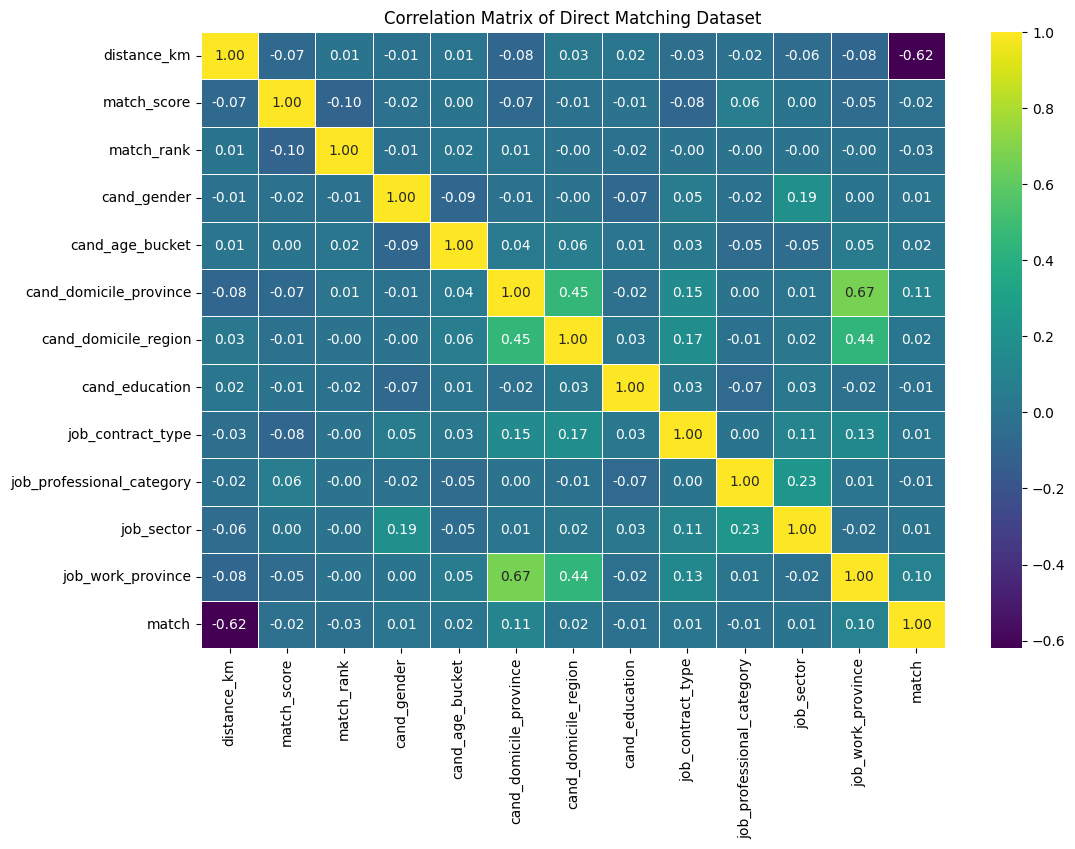

In [222]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the correlation matrix
correlation_matrix = dm_df.corr(numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="viridis", fmt=".2f", linewidths=0.5)

# Customize the plot
plt.title("Correlation Matrix of Direct Matching Dataset")
plt.show()


## 5. AI FAIRNESS 360 - BIAS DETECTION
In this section of the notebook we focus on using the AI fariness 360 tool in order to detect the bias, targeting the match rank column. This will be performed according to:
- Candidate Age Bucket
- Candidate Gender
- Candidate Region

In [223]:
from aif360.datasets import StandardDataset
from aif360.metrics import BinaryLabelDatasetMetric

In order to correctly tackle this problem we are going to use the encoded version of the dataframe (dm_df_encoded)

### 5.1 GENDER BIAS DETECTION

In [224]:
# Retrieve the mapping from LabelEncoder
gender_label_mapping = {index: label for index, label in enumerate(label_encoders["cand_gender"].classes_)}

print("Label Encoding Mapping for gender:", gender_label_mapping)

Label Encoding Mapping for gender: {0: 'Female', 1: 'Male'}


In [225]:
df = dm_df.copy()

# Ensure gender codes are integers
df["cand_gender"] = df["cand_gender"].astype(int)

# Define the target variable (match score threshold for fairness)
df["favorable_outcome"] = (df["match_score"] >= 80).astype(int)  # 1 if match_score ≥ 80

# Keep only necessary columns
df = df[["cand_gender", "favorable_outcome"]]

# Define protected attribute
protected_attribute = "cand_gender"

In [226]:
# Convert dataframe into AIF360 dataset
aif_dataset = StandardDataset(
    df,
    label_name="favorable_outcome",  # The target variable
    favorable_classes=[1],  # Match scores >= 80 are considered favorable
    protected_attribute_names=[protected_attribute],
    privileged_classes=[[1]]  # Female (0) is unprivileged, male (1) is privileged
)

# Compute fairness metrics
metric = BinaryLabelDatasetMetric(
    aif_dataset,
    privileged_groups=[{protected_attribute: 1}],  #privileged males
    unprivileged_groups=[{protected_attribute: 0}]  #unprivileged females
)



In [227]:
print(f"Disparate Impact: {metric.disparate_impact()}")
print(f"Statistical Parity Difference: {metric.statistical_parity_difference()}")
print(f"Mean Difference: {metric.mean_difference()}")

Disparate Impact: 1.0000663372457879
Statistical Parity Difference: 6.628157038235383e-05
Mean Difference: 6.628157038235383e-05


#### MEASURES AND RESULTS
**Disparate Impact** = this measure checks wether the positive outcome rate is different for the privileged group (Males) versus the unprivileged one (Females). Ideally, the results would be equal or close to 1, indicating no presence of bias.
**Statistical Parity Difference** = This measures the difference in favorable outcomes between privileged and unprivileged groups. The goal is to have a value which is close to 0, therefore our results are good.
**Mean Difference** = Similar to SPD but computed as an average difference in selection probabilities. This low value also underlines the absence of bias.

Therefore, in the case of gender we can see that there is almost absolutely no bias. This is to be expected also from the analysis of the data contained in the dataframe.


### 5.2 AGE BUCKET

In [228]:
# Retrieve the mapping from LabelEncoder
age_label_mapping = {index: label for index, label in enumerate(label_encoders["cand_age_bucket"].classes_)}

print("Label Encoding Mapping for age:", age_label_mapping)

Label Encoding Mapping for age: {0: '15-24', 1: '25-34', 2: '35-44', 3: '45-54', 4: '55-74', 5: 'Not disclosed'}


In [229]:
df = dm_df.copy()

# Ensure age bucket codes are integers
df["cand_age_bucket"] = df["cand_age_bucket"].astype(int)

# Define the target variable (match score threshold for fairness)
df["favorable_outcome"] = (df["match_score"] >= 80).astype(int)

# Keep only necessary columns
df = df[["cand_age_bucket", "favorable_outcome"]]

In [230]:
# Define privileged age group (25-34)
privileged_age = [1]

# Convert dataframe into AIF360 dataset
aif_dataset = StandardDataset(
    df,
    label_name="favorable_outcome",
    favorable_classes=[1],
    protected_attribute_names=["cand_age_bucket"],
    privileged_classes=[privileged_age]
)


In [231]:
# Get all age groups except 25-34
all_ages = df["cand_age_bucket"].unique()
unprivileged_ages = [{"cand_age_bucket": r} for r in all_ages if r != 1]

# Store results in a dictionary
fairness_results = []

for age in unprivileged_ages:
    metric = BinaryLabelDatasetMetric(
        aif_dataset,
        privileged_groups=[{"cand_age_bucket": 1}],
        unprivileged_groups=[age]
    )

    fairness_results.append({
        "Age Bucket": age["cand_age_bucket"],
        "Disparate Impact": metric.disparate_impact(),
        "Statistical Parity Difference": metric.statistical_parity_difference()
    })


In [232]:
import pprint

pprint.pprint(fairness_results)

[{'Age Bucket': 3,
  'Disparate Impact': 1.0013642564802183,
  'Statistical Parity Difference': 0.0013623978201634523},
 {'Age Bucket': 2,
  'Disparate Impact': 1.0008945734330887,
  'Statistical Parity Difference': 0.0008933546681935134},
 {'Age Bucket': 0,
  'Disparate Impact': 0.9989913553985116,
  'Statistical Parity Difference': -0.0010072704262820142},
 {'Age Bucket': 4,
  'Disparate Impact': 1.0013642564802183,
  'Statistical Parity Difference': 0.0013623978201634523},
 {'Age Bucket': 5,
  'Disparate Impact': 1.0013642564802183,
  'Statistical Parity Difference': 0.0013623978201634523}]


Also in this case, there is little to no bias

In [233]:
# Convert to DataFrame for visualization
fairness_df = pd.DataFrame(fairness_results)

# Fill missing fairness values to avoid errors
fairness_df = fairness_df.fillna(0)

# Sort age groups for better visualization
fairness_df = fairness_df.sort_values(by="Disparate Impact")

age_label_mapping = {
    0: '15-24', 1: '25-34', 2: '35-44', 3: '45-54', 4: '55-74'}


# Map age group numbers to names & fill missing values
fairness_df["Age Bucket"] = fairness_df["Age Bucket"].map(age_label_mapping).fillna("Unknown Age")

C:\Users\annad\AppData\Local\Temp\ipykernel_38640\1979952009.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Age Bucket", y="Disparate Impact", data=fairness_df, palette="viridis")
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.g

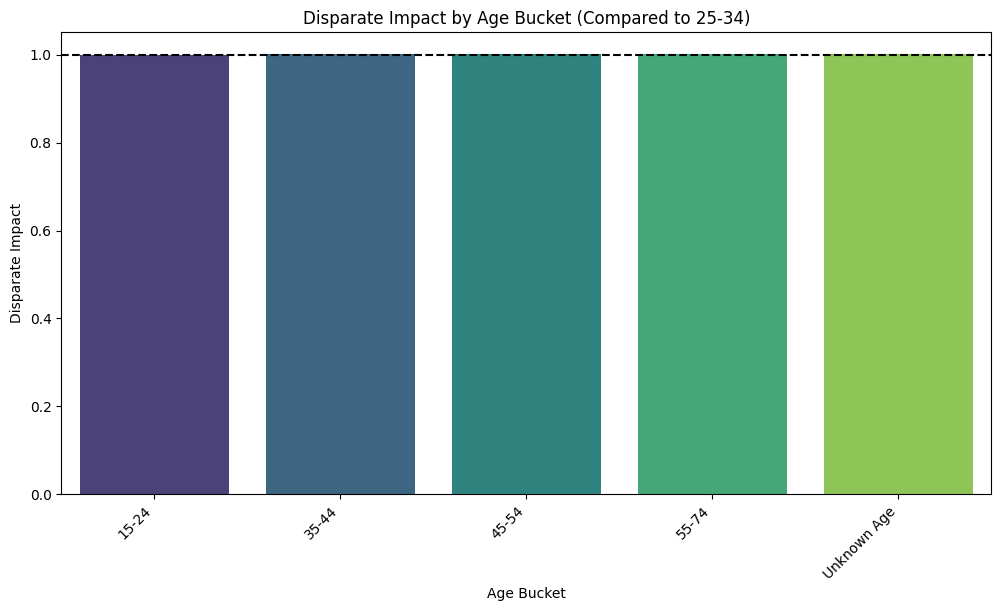

In [234]:
plt.figure(figsize=(12, 6))
sns.barplot(x="Age Bucket", y="Disparate Impact", data=fairness_df, palette="viridis")
plt.axhline(y=1, color="black", linestyle="--")
plt.xlabel("Age Bucket")
plt.ylabel("Disparate Impact")
plt.title("Disparate Impact by Age Bucket (Compared to 25-34)")
plt.xticks(rotation=45, ha="right")
plt.show()

C:\Users\annad\AppData\Local\Temp\ipykernel_38640\741814665.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Age Bucket", y="Statistical Parity Difference", data=fairness_df, palette="viridis")
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = gr

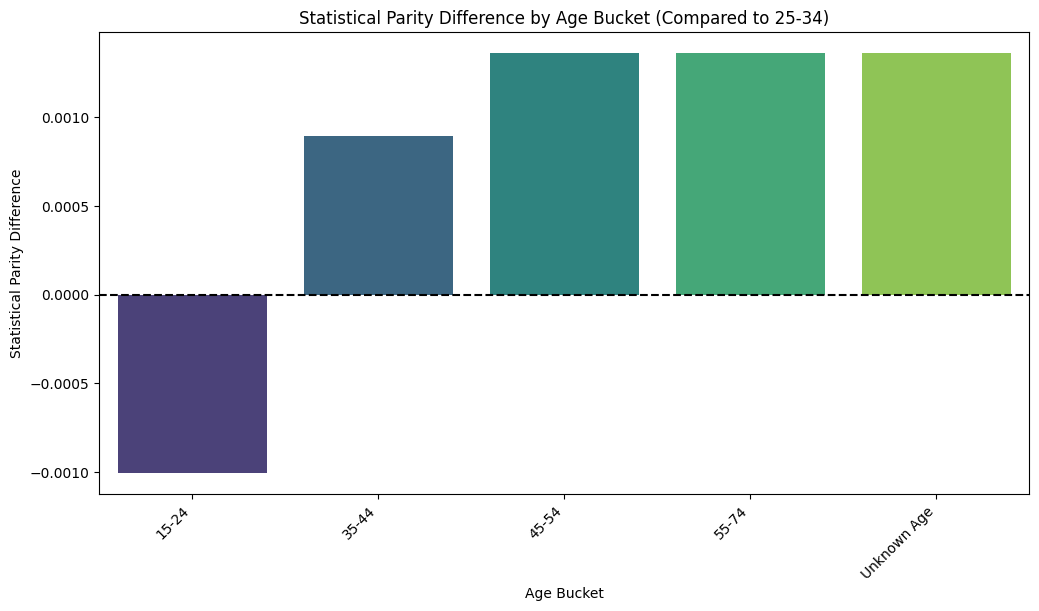

In [235]:
fairness_df = fairness_df.sort_values(by="Statistical Parity Difference")

plt.figure(figsize=(12, 6))
sns.barplot(x="Age Bucket", y="Statistical Parity Difference", data=fairness_df, palette="viridis")
plt.axhline(y=0, color="black", linestyle="--")
plt.xlabel("Age Bucket")
plt.ylabel("Statistical Parity Difference")
plt.title("Statistical Parity Difference by Age Bucket (Compared to 25-34)")
plt.xticks(rotation=45, ha="right")
plt.show()

### 5.3 REGION

In [236]:
# Retrieve the mapping from LabelEncoder
region_label_mapping = {index: label for index, label in enumerate(label_encoders["cand_domicile_region"].classes_)}

print("Label Encoding Mapping for Regions:", region_label_mapping)


Label Encoding Mapping for Regions: {0: 'ABRUZZO', 1: 'CALABRIA', 2: 'CAMPANIA', 3: 'EMILIA ROMAGNA', 4: 'FRIULI VENEZIA GIULIA', 5: 'LAZIO', 6: 'LIGURIA', 7: 'LOMBARDIA', 8: 'MARCHE', 9: 'MOLISE', 10: 'Not disclosed', 11: 'PIEMONTE', 12: 'PUGLIA', 13: 'SARDEGNA', 14: 'TOSCANA', 15: 'TRENTINO ALTO ADIGE', 16: 'UMBRIA', 17: "VALLE D'AOSTA", 18: 'VENETO'}


The region that appears most times is Lombardia (number 7), and therefore we want to check for bias in that sense.

In [237]:
df = dm_df.copy()

# Ensure region codes are integers
df["cand_domicile_region"] = df["cand_domicile_region"].astype(int)

# Define the target variable (match score threshold for fairness)
df["favorable_outcome"] = (df["match_score"] >= 80).astype(int)  # 1 if match_score ≥ 80

# Keep only necessary columns
df = df[["cand_domicile_region", "favorable_outcome"]]

In [238]:
# Define privileged region (Lombardia = 7)
privileged_region = [7]

# Convert dataframe into AIF360 dataset
aif_dataset = StandardDataset(
    df,
    label_name="favorable_outcome",
    favorable_classes=[1],
    protected_attribute_names=["cand_domicile_region"],
    privileged_classes=[privileged_region]
)

In [239]:
# Get all regions except Lombardia
all_regions = df["cand_domicile_region"].unique()
unprivileged_regions = [{"cand_domicile_region": r} for r in all_regions if r != 7]

fairness_results = []

for region in unprivileged_regions:
    metric = BinaryLabelDatasetMetric(
        aif_dataset,
        privileged_groups=[{"cand_domicile_region": 7}],
        unprivileged_groups=[region]
    )

    fairness_results.append({
        "Region": region["cand_domicile_region"],
        "Disparate Impact": metric.disparate_impact(),
        "Statistical Parity Difference": metric.statistical_parity_difference()
    })


In [240]:
pprint.pprint(fairness_results)

[{'Disparate Impact': 0.9836512261580381,
  'Region': 4,
  'Statistical Parity Difference': -0.016348773841961872},
 {'Disparate Impact': 1.0, 'Region': 0, 'Statistical Parity Difference': 0.0},
 {'Disparate Impact': 1.0, 'Region': 9, 'Statistical Parity Difference': 0.0},
 {'Disparate Impact': 1.0, 'Region': 11, 'Statistical Parity Difference': 0.0},
 {'Disparate Impact': 0.9991769547325103,
  'Region': 18,
  'Statistical Parity Difference': -0.0008230452674896638},
 {'Disparate Impact': 1.0, 'Region': 3, 'Statistical Parity Difference': 0.0},
 {'Disparate Impact': 1.0, 'Region': 2, 'Statistical Parity Difference': 0.0},
 {'Disparate Impact': 1.0, 'Region': 17, 'Statistical Parity Difference': 0.0},
 {'Disparate Impact': 1.0, 'Region': 5, 'Statistical Parity Difference': 0.0},
 {'Disparate Impact': 1.0, 'Region': 15, 'Statistical Parity Difference': 0.0},
 {'Disparate Impact': 1.0, 'Region': 13, 'Statistical Parity Difference': 0.0},
 {'Disparate Impact': 1.0, 'Region': 14, 'Statistic

This shows that there is no bias linked to this, although there are some interesting regions: Emilia Romagna and Veneto.

In [241]:
# Convert to DataFrame for visualization
fairness_df = pd.DataFrame(fairness_results)

# Fill missing fairness values to avoid errors
fairness_df = fairness_df.fillna(0)

# Sort regions for better visualization
fairness_df = fairness_df.sort_values(by="Disparate Impact")

region_label_mapping = {0: 'ABRUZZO', 1: 'CALABRIA', 2: 'CAMPANIA',
                        3: 'EMILIA ROMAGNA', 4: 'FRIULI VENEZIA GIULIA', 5: 'LAZIO', 6: 'LIGURIA',
                        7: 'LOMBARDIA', 8: 'MARCHE', 9: 'MOLISE', 10: 'Not disclosed', 11: 'PIEMONTE', 12: 'PUGLIA',
                        13: 'SARDEGNA', 14: 'TOSCANA', 15: 'TRENTINO ALTO ADIGE', 16: 'UMBRIA', 17: "VALLE D'AOSTA", 18: 'VENETO'
                    }

# Map region numbers to names & fill missing values
fairness_df["Region"] = fairness_df["Region"].map(region_label_mapping).fillna("Unknown Region")

C:\Users\annad\AppData\Local\Temp\ipykernel_38640\2880959173.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Region", y="Disparate Impact", data=fairness_df, palette="viridis")
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_g

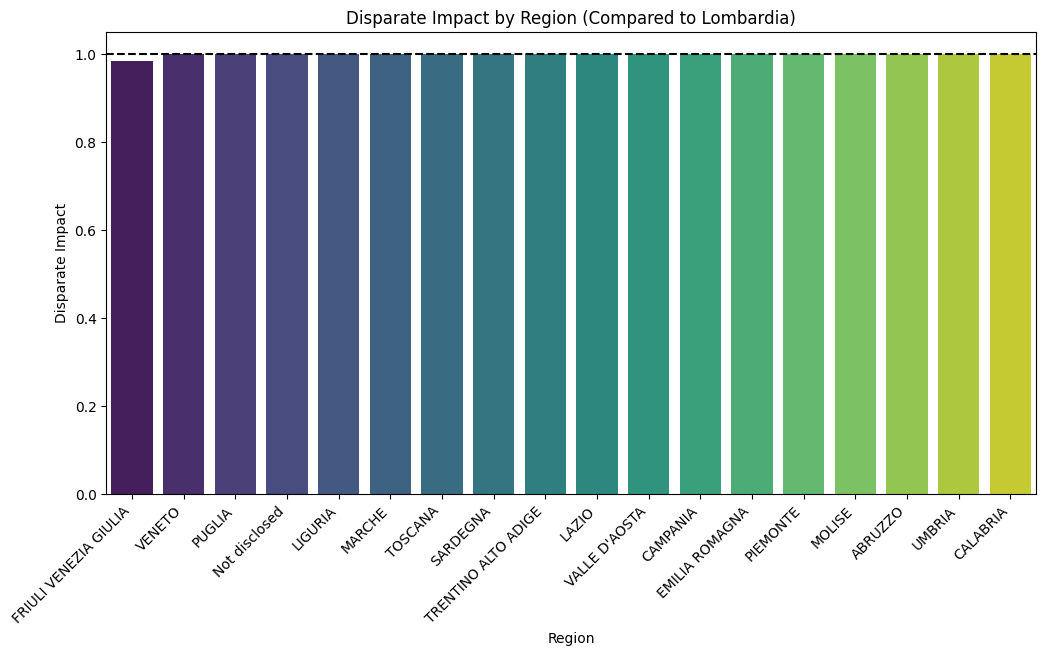

In [242]:
plt.figure(figsize=(12, 6))
sns.barplot(x="Region", y="Disparate Impact", data=fairness_df, palette="viridis")
plt.axhline(y=1, color="black", linestyle="--")
plt.xlabel("Region")
plt.ylabel("Disparate Impact")
plt.title("Disparate Impact by Region (Compared to Lombardia)")
plt.xticks(rotation=45, ha="right")
plt.show()

Still, Lombardia is not the only prominent region, as also Emilia Romagna and Veneto appear quite often. Therefore, we can check for bias also in that sense.

In [243]:
# Define privileged regions: Lombardia (7), Emilia Romagna (4), Veneto (18)
privileged_region = [7, 4, 18]

# Convert dataframe into AIF360 dataset
aif_dataset = StandardDataset(
    df,
    label_name="favorable_outcome",
    favorable_classes=[1],
    protected_attribute_names=["cand_domicile_region"],
    privileged_classes=[privileged_region]
)

In [244]:
# Get all regions except Lombardia
all_regions = df["cand_domicile_region"].unique()
unprivileged_regions = [{"cand_domicile_region": r} for r in all_regions if r not in privileged_region]
fairness_results = []

for region in unprivileged_regions:
    metric = BinaryLabelDatasetMetric(
        aif_dataset,
        privileged_groups=[{"cand_domicile_region": r} for r in privileged_region],
        unprivileged_groups=[region]
    )

    fairness_results.append({
        "Region": region["cand_domicile_region"],
        "Disparate Impact": metric.disparate_impact(),
        "Statistical Parity Difference": metric.statistical_parity_difference()
    })


In [245]:
pprint.pprint(fairness_results)

[{'Disparate Impact': 1.001258087706686,
  'Region': 0,
  'Statistical Parity Difference': 0.0012565069107880467},
 {'Disparate Impact': 1.001258087706686,
  'Region': 9,
  'Statistical Parity Difference': 0.0012565069107880467},
 {'Disparate Impact': 1.001258087706686,
  'Region': 11,
  'Statistical Parity Difference': 0.0012565069107880467},
 {'Disparate Impact': 1.001258087706686,
  'Region': 3,
  'Statistical Parity Difference': 0.0012565069107880467},
 {'Disparate Impact': 1.001258087706686,
  'Region': 2,
  'Statistical Parity Difference': 0.0012565069107880467},
 {'Disparate Impact': 1.001258087706686,
  'Region': 17,
  'Statistical Parity Difference': 0.0012565069107880467},
 {'Disparate Impact': 1.001258087706686,
  'Region': 5,
  'Statistical Parity Difference': 0.0012565069107880467},
 {'Disparate Impact': 1.001258087706686,
  'Region': 15,
  'Statistical Parity Difference': 0.0012565069107880467},
 {'Disparate Impact': 1.001258087706686,
  'Region': 13,
  'Statistical Parit

In [246]:
# Convert to DataFrame for visualization
fairness_df = pd.DataFrame(fairness_results)

# Fill missing fairness values to avoid errors
fairness_df = fairness_df.fillna(0)

# Sort regions for better visualization
fairness_df = fairness_df.sort_values(by="Disparate Impact")

region_label_mapping = {0: 'ABRUZZO', 1: 'CALABRIA', 2: 'CAMPANIA',
                        3: 'EMILIA ROMAGNA', 4: 'FRIULI VENEZIA GIULIA', 5: 'LAZIO', 6: 'LIGURIA',
                        7: 'LOMBARDIA', 8: 'MARCHE', 9: 'MOLISE', 10: 'Not disclosed', 11: 'PIEMONTE', 12: 'PUGLIA',
                        13: 'SARDEGNA', 14: 'TOSCANA', 15: 'TRENTINO ALTO ADIGE', 16: 'UMBRIA', 17: "VALLE D'AOSTA", 18: 'VENETO'
                    }

# Map region numbers to names & fill missing values
fairness_df["Region"] = fairness_df["Region"].map(region_label_mapping).fillna("Unknown Region")

C:\Users\annad\AppData\Local\Temp\ipykernel_38640\1032924590.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Region", y="Disparate Impact", data=fairness_df, palette="viridis")
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_g

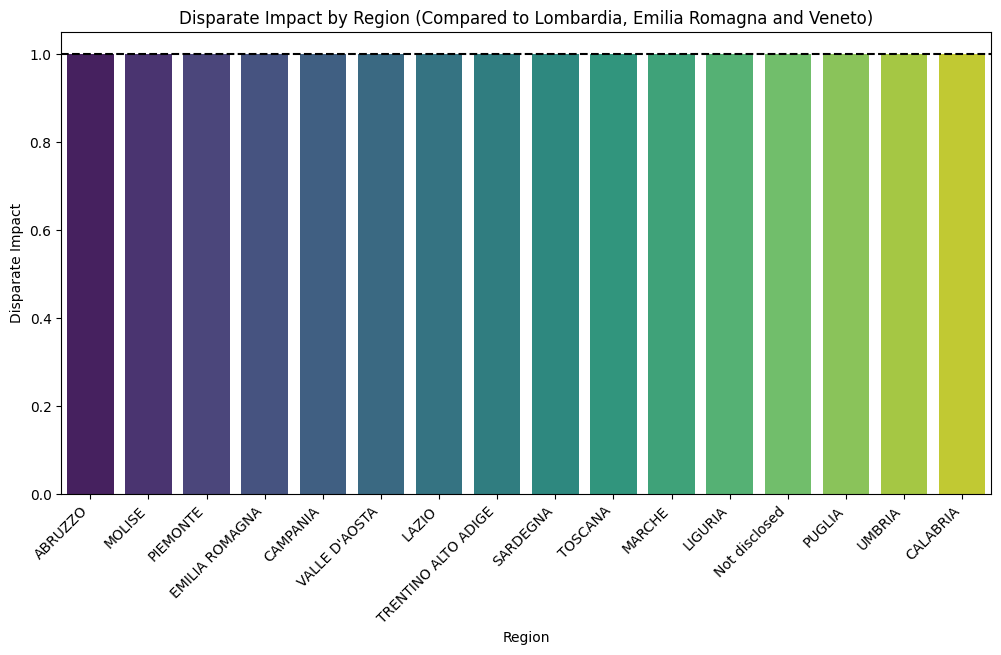

In [247]:
plt.figure(figsize=(12, 6))
sns.barplot(x="Region", y="Disparate Impact", data=fairness_df, palette="viridis")
plt.axhline(y=1, color="black", linestyle="--")
plt.xlabel("Region")
plt.ylabel("Disparate Impact")
plt.title("Disparate Impact by Region (Compared to Lombardia, Emilia Romagna and Veneto)")
plt.xticks(rotation=45, ha="right")
plt.show()

### 5.4 MATCHING PROVINCE

In [248]:
dm_df.head()

,cand_id,job_id,distance_km,match_score,match_rank,cand_gender,cand_age_bucket,cand_domicile_province,cand_domicile_region,cand_education,job_contract_type,job_professional_category,job_sector,job_work_province,match,job_type
0,"5,664,912",OFF_1011_1427,32.327042,99.573387,1,1,3,73,4,327,2,166,7,48,1,OFF
1,"4,999,120",OFF_1011_1427,15.595593,99.210564,2,1,2,73,4,327,2,166,7,48,1,OFF
2,"5,413,671",OFF_1011_1427,31.348877,99.118614,3,0,3,73,4,327,2,166,7,48,1,OFF
3,"5,965,090",OFF_1011_1427,66.315598,97.409767,4,1,0,71,4,327,2,166,7,48,0,OFF
4,"5,771,219",OFF_1011_1427,15.595593,97.323875,5,0,2,73,4,327,2,166,7,48,1,OFF


In [249]:
df = dm_df.copy()

df["successful_placement"] = (df["match_score"] >= 80).astype(int)

df_province = df[["match", "successful_placement"]]

aif_dataset = StandardDataset(
    df_province,
    label_name="successful_placement",
    favorable_classes=[1],
    protected_attribute_names=["match"],  # Whether candidate is working in the same province
    privileged_classes=[[1]]  # Candidates working in the same province are privileged
)

In [250]:
# Define privileged (local placements) and unprivileged (relocation) groups
privileged_groups = [{"match": 1}]
unprivileged_groups = [{"match": 0}]

metric = BinaryLabelDatasetMetric(
    aif_dataset,
    privileged_groups=privileged_groups,
    unprivileged_groups=unprivileged_groups
)

print(f"Disparate Impact: {metric.disparate_impact()}")
print(f"Statistical Parity Difference: {metric.statistical_parity_difference()}")

Disparate Impact: 1.001042501616031
Statistical Parity Difference: 0.0010411555842478881


C:\Users\annad\AppData\Local\Temp\ipykernel_38640\3566764820.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Metric", y="Value", data=fairness_df, palette="viridis")
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key

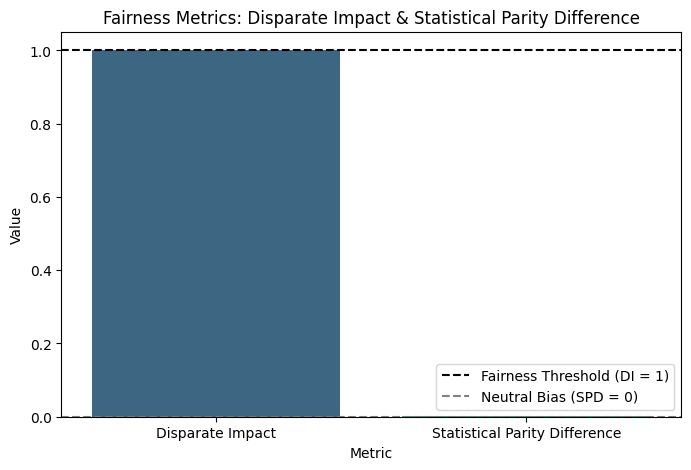

In [251]:
fairness_results = {
    "Metric": ["Disparate Impact", "Statistical Parity Difference"],
    "Value": [metric.disparate_impact(), metric.statistical_parity_difference()]
}

fairness_df = pd.DataFrame(fairness_results)

plt.figure(figsize=(8, 5))
sns.barplot(x="Metric", y="Value", data=fairness_df, palette="viridis")
plt.axhline(y=1, color="black", linestyle="--", label="Fairness Threshold (DI = 1)")
plt.axhline(y=0, color="gray", linestyle="--", label="Neutral Bias (SPD = 0)")
plt.ylabel("Value")
plt.title("Fairness Metrics: Disparate Impact & Statistical Parity Difference")
plt.legend()
plt.show()

# APPENDIX

## Alternative bias detection

Further techniques were applied for bias detection in order to deepen our analysis and understanding of the topic. We would also like to further confirm that the dataset is indeed unbiased. 

### Chi-squared and KL divergence

**gender**

In [260]:
df = dm_df.copy()

df["cand_gender"] = df["cand_gender"].astype(int)

df["favorable_outcome"] = (df["match_score"] >= 80).astype(int)

privileged_group = df[df["cand_gender"] == 1]
unprivileged_group = df[df["cand_gender"] == 0]

# Compute rates
privileged_rate = privileged_group["favorable_outcome"].mean()
unprivileged_rate = unprivileged_group["favorable_outcome"].mean()

# Compute fairness metrics
statistical_parity_difference = unprivileged_rate - privileged_rate
mean_difference = statistical_parity_difference
disparate_impact = unprivileged_rate / privileged_rate if privileged_rate > 0 else np.nan

# Chi-Square Test for independence
contingency_table = pd.crosstab(df["cand_gender"], df["favorable_outcome"])
chi2, p, _, _ = chi2_contingency(contingency_table)

# Define metadata for SDV
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df)

# Generate synthetic data using SDV GaussianCopulaSynthesizer
synthesizer = GaussianCopulaSynthesizer(metadata)
synthesizer.fit(df)
synth_data = synthesizer.sample(len(df))

# Compute KL Divergence for bias detection
real_gender_dist = df["cand_gender"].value_counts(normalize=True).sort_index()
synth_gender_dist = synth_data["cand_gender"].value_counts(normalize=True).sort_index()
kl_divergence = entropy(real_gender_dist, synth_gender_dist)

# Print fairness metrics
print(f"Disparate Impact: {disparate_impact:.4f}")
print(f"Statistical Parity Difference: {statistical_parity_difference:.4f}")
print(f"Mean Difference: {mean_difference:.4f}")
print(f"Chi-Square Test p-value: {p:.4f}")
print(f"KL Divergence (Real vs. Synthetic): {kl_divergence:.4f}")

if p < 0.05:
    print("Significant bias detected based on Chi-Square Test.")
else:
    print("No significant bias detected based on Chi-Square Test.")

if kl_divergence > 0.1:  # Threshold can be adjusted based on needs
    print("Potential bias detected due to significant KL Divergence.")
else:
    print("No significant bias detected based on KL Divergence.")


c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\sdv\single_table\base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\sdv\single_table\base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Disparate Impact: 1.0001
Statistical Parity Difference: 0.0001
Mean Difference: 0.0001
Chi-Square Test p-value: 1.0000
KL Divergence (Real vs. Synthetic): 0.0000
No significant bias detected based on Chi-Square Test.
No significant bias detected based on KL Divergence.


In [261]:
from scipy.stats import chi2_contingency
import numpy as np

# Compute Chi-Square test
contingency_table = pd.crosstab(df["cand_gender"], df["favorable_outcome"])
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Compute Cramér’s V
n = np.sum(contingency_table.values)
phi2 = chi2 / n
r, k = contingency_table.shape
cramers_v = np.sqrt(phi2 / min(r-1, k-1))

print(f"Cramér’s V: {cramers_v:.4f}")

Cramér’s V: 0.0000


Cramer's V, which measures the strength of the bias, confirms the absence of bias in this context. 

**age bucket**

In [262]:
df = dm_df.copy()

df["cand_age_bucket"] = df["cand_age_bucket"].astype(int)

df["favorable_outcome"] = (df["match_score"] >= 80).astype(int)

# Compute group proportions
privileged_group = df[df["cand_age_bucket"] == 1]
unprivileged_group = df[df["cand_age_bucket"] != 1]

# Compute rates
privileged_rate = privileged_group["favorable_outcome"].mean()
unprivileged_rate = unprivileged_group["favorable_outcome"].mean()

# Compute fairness metrics
statistical_parity_difference = unprivileged_rate - privileged_rate
mean_difference = statistical_parity_difference
disparate_impact = unprivileged_rate / privileged_rate if privileged_rate > 0 else np.nan

# Chi-Square Test for independence
contingency_table = pd.crosstab(df["cand_age_bucket"], df["favorable_outcome"])
chi2, p, _, _ = chi2_contingency(contingency_table)

# Define metadata for SDV
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df)

# Generate synthetic data using SDV GaussianCopulaSynthesizer
synthesizer = GaussianCopulaSynthesizer(metadata)
synthesizer.fit(df)
synth_data = synthesizer.sample(len(df))

# Compute KL Divergence for bias detection
real_age_dist = df["cand_age_bucket"].value_counts(normalize=True).sort_index()
synth_age_dist = synth_data["cand_age_bucket"].value_counts(normalize=True).sort_index()
kl_divergence = entropy(real_age_dist, synth_age_dist)

# Print fairness metrics
print(f"Disparate Impact: {disparate_impact:.4f}")
print(f"Statistical Parity Difference: {statistical_parity_difference:.4f}")
print(f"Mean Difference: {mean_difference:.4f}")
print(f"Chi-Square Test p-value: {p:.4f}")
print(f"KL Divergence (Real vs. Synthetic): {kl_divergence:.4f}")

# Interpret results
if p < 0.05:
    print("Significant bias detected based on Chi-Square Test.")
else:
    print("No significant bias detected based on Chi-Square Test.")

if kl_divergence > 0.1:
    print("Potential bias detected due to significant KL Divergence.")
else:
    print("No significant bias detected based on KL Divergence.")

c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\sdv\single_table\base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\sdv\single_table\base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Disparate Impact: 1.0008
Statistical Parity Difference: 0.0008
Mean Difference: 0.0008
Chi-Square Test p-value: 0.2900
KL Divergence (Real vs. Synthetic): 0.0003
No significant bias detected based on Chi-Square Test.
No significant bias detected based on KL Divergence.


In [263]:
from scipy.stats import chi2_contingency
import numpy as np

# Compute Chi-Square test
contingency_table = pd.crosstab(df["cand_age_bucket"], df["favorable_outcome"])
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Compute Cramér’s V
n = np.sum(contingency_table.values)
phi2 = chi2 / n
r, k = contingency_table.shape
cramers_v = np.sqrt(phi2 / min(r-1, k-1))

print(f"Cramér’s V: {cramers_v:.4f}")

Cramér’s V: 0.0267


**domicile region**

In [264]:
df = dm_df.copy()

privileged_regions = [7, 4, 18]
df["privileged"] = df["cand_domicile_region"].isin(privileged_regions).astype(int)

df["favorable_outcome"] = (df["match_score"] >= 80).astype(int)

# Chi-Square Test for independence
contingency_table = pd.crosstab(df["privileged"], df["favorable_outcome"])
chi2, p, _, _ = chi2_contingency(contingency_table)

# Define metadata for SDV
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df)

# Generate synthetic data using SDV GaussianCopulaSynthesizer
synthesizer = GaussianCopulaSynthesizer(metadata)
synthesizer.fit(df)
synth_data = synthesizer.sample(len(df))

# Compute KL Divergence for bias detection
real_region_dist = df["cand_domicile_region"].value_counts(normalize=True).sort_index()
synth_region_dist = synth_data["cand_domicile_region"].value_counts(normalize=True).sort_index()
kl_divergence = entropy(real_region_dist, synth_region_dist)

# Print results
print(f"Chi-Square Test p-value: {p:.4f}")
print(f"KL Divergence (Real vs. Synthetic): {kl_divergence:.4f}")

# Interpret results
if p < 0.05:
    print("Significant bias detected based on Chi-Square Test.")
else:
    print("No significant bias detected based on Chi-Square Test.")

if kl_divergence > 0.1:
    print("Potential bias detected due to significant KL Divergence.")
else:
    print("No significant bias detected based on KL Divergence.")

c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\sdv\single_table\base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
c:\Users\annad\AppData\Local\Programs\Python\Python311\Lib\site-packages\sdv\single_table\base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Chi-Square Test p-value: 0.1160
KL Divergence (Real vs. Synthetic): 1.2580
No significant bias detected based on Chi-Square Test.
Potential bias detected due to significant KL Divergence.


In this case the KL divergence method shows that there could be some bias. The reasoning behind this discrepancy in the results could be that KL divergence works in a different way with respect to the previously explored methods (Aif360 and Chi-Square Test). This makes it extremely sensitive to small shifts in the distribution, and therefore the presence of bias needs to be tested more.

In [265]:
from scipy.stats import chi2_contingency
import numpy as np

# Compute Chi-Square test
contingency_table = pd.crosstab(df["cand_domicile_region"], df["favorable_outcome"])
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Compute Cramér’s V
n = np.sum(contingency_table.values)
phi2 = chi2 / n
r, k = contingency_table.shape
cramers_v = np.sqrt(phi2 / min(r-1, k-1))

print(f"Cramér’s V: {cramers_v:.4f}")

Cramér’s V: 0.1155


In this case Cramer's V has a much higher value compared to what we have seen before. This means that in this specific context there might be bias. 

### FairLearn tool
Following the idea that some more methods need to be explored, the following implementation is the FairLearn tool, which is a python library created with the sole purpose of detecting and mitigating bias in dataframes. 

In [255]:
from fairlearn.metrics import demographic_parity_difference
df1 = dm_df.copy()

df1["cand_domicile_region"] = df1["cand_domicile_region"].astype(int)

df1["favorable_outcome"] = (df1["match_score"] >= 80).astype(int)

df1["predicted_outcome"] = df1["favorable_outcome"]

df1 = df1[["cand_domicile_region", "favorable_outcome", "predicted_outcome"]]

# Define variables
y_true = df1["favorable_outcome"]
y_pred = df1["predicted_outcome"]
protected_attr = df1["cand_domicile_region"]

# Compute bias metrics
dp_diff = demographic_parity_difference(y_true, y_pred, sensitive_features=protected_attr)

print(f"Demographic Parity Difference: {dp_diff}")

Demographic Parity Difference: 0.016348773841961872


In order to have bias detected, this value should be much higher, and therefore this method shows no bias. 

### Wasserstein distance and Jensen-Shannon Divergence

In [256]:
from scipy.stats import wasserstein_distance, entropy

df = dm_df.copy()

privileged_regions = [7, 4, 18]
df["privileged"] = df["cand_domicile_region"].isin(privileged_regions).astype(int)

df["favorable_outcome"] = (df["match_score"] >= 80).astype(int)

# Compute Wasserstein Distance (Earth Mover’s Distance)
privileged_dist = df[df["privileged"] == 1]["cand_domicile_region"].values
unprivileged_dist = df[df["privileged"] == 0]["cand_domicile_region"].values
wasserstein_dist = wasserstein_distance(privileged_dist, unprivileged_dist)
print(f"Wasserstein Distance: {wasserstein_dist:.4f}")

# Compute Jensen-Shannon Divergence
def js_divergence(p, q):
    p = np.array(p, dtype=np.float64)
    q = np.array(q, dtype=np.float64)
    p /= p.sum()
    q /= q.sum()
    m = (p + q) / 2
    return (entropy(p, m) + entropy(q, m)) / 2

# Get probability distributions for cand_domicile_region
dist_privileged = np.bincount(privileged_dist, minlength=df["cand_domicile_region"].max() + 1)
dist_unprivileged = np.bincount(unprivileged_dist, minlength=df["cand_domicile_region"].max() + 1)

js_div = js_divergence(dist_privileged, dist_unprivileged)
print(f"Jensen-Shannon Divergence: {js_div:.4f}")


Wasserstein Distance: 3.6462
Jensen-Shannon Divergence: 0.6931


Also in this case we can detect bias with respect to the most privileged classes (the regions Lombarida, Emilia Romagna and Veneto). This could be because these metrics (Wasserstein Distance and Jensen-Shannon Divergence), as well as the previously used KL divergence, are all extremely sensitive to distributional imbalance. This is of course the case for the regions, where the three privileged appear in the dataset much more than the others. This is why in these cases bias is detected, while for aif360 and chi-squared we seem to not notice any bias at all. 

This hypothesis is confirmed by some literature studies, specifically the article by Kwekir-Aggrey, Kweku and Brown, Sarah M, called: **“Measuring Bias with Wasserstein Distance.”**, published in 2020. The article is available at the following link: https://securedata.lol/camera_ready/37.pdf. 

### Bias mitigation

Since bias was detected, we decided to explore a technique to try to mitigate it. The one taken into consideration is called SMOTE, and it works by oversampling the minority class(es) in order to produce a more balanced dataset. 

In [257]:
import pandas as pd
from imblearn.over_sampling import SMOTE

df = dm_df.copy()

#drop non numerical because SMOTE cannot produce data for those
df.drop(columns=['cand_id', 'job_id', 'job_type'], inplace=True)

privileged_regions = [7, 4, 18]
df["privileged"] = df["cand_domicile_region"].isin(privileged_regions).astype(int)

df["favorable_outcome"] = (df["match_score"] >= 80).astype(int)

X = df.drop(columns=["favorable_outcome"])
y = df["favorable_outcome"]

smote = SMOTE(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled["favorable_outcome"] = y_resampled

print("Original class distribution:")
print(df["favorable_outcome"].value_counts())
print("\nResampled class distribution:")
print(df_resampled["favorable_outcome"].value_counts())


Original class distribution:
favorable_outcome
1    8640
0       7
Name: count, dtype: int64

Resampled class distribution:
favorable_outcome
1    8640
0    8640
Name: count, dtype: int64


We see that SMOTE gives perfect results, completely removing the bias from the data.